# SmartViz-ML:
## An Explainable Machine Learning Framework for Automated Business Visualization and Decision Support

---
#### **Author**: Moïse Kambale Kasambya
###
#### **Supervisor**: Richelle Ann B. Juayong, PhD

#### University of the Philippines Diliman
#### College of Engineering

**Dataset:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Online+Retail+II)

### Research Questions
- **RQ1.** Can SmartViz automatically identify the most appropriate visualization for a business analytical task?
- **RQ2.** Does the proposed ML framework improve business prediction performance compared with conventional approaches?
- **RQ3.** Can explainable AI improve the interpretability of the generated business insights?
- **RQ4.** Does SmartViz provide useful and actionable recommendations for business decision-making?

### Pipeline Overview
```
0a. Imports & Global Constants
0b. Helper Functions
01. Data Loading & EDA
02. Data Preprocessing
03. Feature Engineering
04. Module A — Customer Segmentation
05. Module B — Sales Forecasting
06. Module C — Anomaly Detection
07. Module D — Smartviz-ML
07a. Meta-Feature Profiles & Rule Based Baseline
07b. Pool A & B Construction
07c. Pool C — Independent Test Set
0Td. Leakage Check
08. Train Recommendation Models
09. Model Selection on Pool B
10. Explainability — Permutation Importance
11a. Final Benchmark Results — Pool C
11b. Statistical Analysis
11c. Granular Evaluation — Domain / Ambiguity / Chart Type
11d. Confusion Matrix & Error Analysis
11e. Ablation Study
12. Pool D —> Final Held-out Evaluation
13. Human Evaluation
14. Business Decision Support
15. Cross — Domain Generalization of Intent Features
16. Benchmark Transparency Table
17. Model Export
18. Clean — Kernel Smoke Test

```


## 0. Imports & Global Constants

In [1]:
import warnings, os, re, json, logging
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'figure.dpi':110,'figure.figsize':(12,5)})

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
    mean_absolute_error, mean_squared_error, f1_score,
    confusion_matrix, classification_report)
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier,
    IsolationForest)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance as perm_imp
from scipy.stats import wilcoxon
from itertools import combinations
import joblib

try:
    import xgboost as xgb; XGB_AVAILABLE=True
except ImportError:
    XGB_AVAILABLE=False
try:
    import lightgbm as lgb; LGB_AVAILABLE=True
except ImportError:
    LGB_AVAILABLE=False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

VIZ_TYPES = ['line_chart','bar_chart','scatter_plot','pie_chart',
             'histogram','box_plot','heatmap','choropleth']

META_FEATURE_COLS = ['n_numeric','n_categorical','n_datetime','max_cardinality',
                     'mean_correlation','missing_ratio','has_temporal','has_geo']

INTENT_KEYWORDS = {
    'kw_temporal':    r'trend|over time|evolution|monthly|weekly|daily|forecast|growth|decline',
    'kw_rank':        r'top|best|worst|rank|most|least|highest|lowest|leading',
    'kw_compare':     r'compare|comparison|versus|vs\b|between|difference',
    'kw_proportion':  r'proportion|share|percentage|part|breakdown|contribution',
    'kw_distribution':r'distribution|spread|range|histogram|frequency|quartile|outlier',
    'kw_correlation': r'correlation|relationship|association|scatter|link',
    'kw_geographic':  r'map|region|country|geographic|location|where',
    'kw_segment':     r'segment|cluster|group|profile|category',
    'kw_anomaly':     r'anomaly|outlier|unusual|suspicious|extreme|abnormal',
    'kw_prediction':  r'predict|forecast|future|next|expect',
}
FEATURE_COLS  = META_FEATURE_COLS + list(INTENT_KEYWORDS.keys())
N_BOOTSTRAP   = 2_000
LIKERT_DIMS   = ['Relevance','Readability','Usefulness','Interpretability']
N_TS_SPLITS   = 5
TS_TEST_SIZE  = 3
N_CLUSTERS    = 5
SEGMENT_NAMES = ['VIP','Loyal','Potential','Occasional','At-Risk']

print("Imports OK")
print(f"XGBoost : {'yes' if XGB_AVAILABLE else 'NO — excluded'}")
print(f"LightGBM: {'yes' if LGB_AVAILABLE else 'NO — excluded'}")
print(f"Feature vector width: {len(FEATURE_COLS)}")


Imports OK
XGBoost : yes
LightGBM: yes
Feature vector width: 18


## 0b. Helper Functions

In [2]:
def encode_query(query):
    q = query.lower()
    return {kw: int(bool(re.search(pat,q))) for kw,pat in INTENT_KEYWORDS.items()}

def extract_meta(df):
    num_c  = df.select_dtypes('number').columns.tolist()
    cat_c  = df.select_dtypes(['object','category','string']).columns.tolist()
    date_c = df.select_dtypes('datetime').columns.tolist()
    card   = max((df[c].nunique() for c in cat_c), default=0)
    if len(num_c)>=2:
        cm = df[num_c].corr().abs()
        mc = float(np.mean([cm.loc[r,c] for r in cm.index for c in cm.columns if r!=c]))
    else:
        mc = 0.0
    return dict(n_numeric=len(num_c),n_categorical=len(cat_c),n_datetime=len(date_c),
                max_cardinality=card,mean_correlation=mc,
                missing_ratio=float(df.isnull().mean().mean()),
                has_temporal=int(len(date_c)>0),
                has_geo=int(any('country' in c.lower() for c in df.columns)))

# Ranking metrics 
def dcg(ranked, relevant, k=3):
    for i,v in enumerate(ranked[:k]):
        if v==relevant: return 1.0/np.log2(i+2)
    return 0.0
IDCG = 1.0/np.log2(2)

def per_query_metrics(predict_fn, X, y, df_q, le, k=3):
    acc1,mrr,ndcg,pred1 = [],[],[],[]
    for i,(xr,yt) in enumerate(zip(X,y)):
        ranked  = predict_fn(xr.reshape(1,-1), df_q.iloc[i]['query'])
        true_v  = le.classes_[yt]
        hit     = int(ranked[0]==true_v)
        rr      = next((1/(r+1) for r,v in enumerate(ranked) if v==true_v),0.0)
        n       = dcg(ranked,true_v,k)/IDCG
        acc1.append(hit); mrr.append(rr); ndcg.append(n)
        pred1.append(le.transform([ranked[0]])[0])
    return np.array(acc1),np.array(mrr),np.array(ndcg),np.array(pred1)

def evaluate_model(name, predict_fn, X, y, df_q, le, k=3):
    acc1,mrr,ndcg,pred1 = per_query_metrics(predict_fn,X,y,df_q,le,k)
    acc3 = np.mean([int(le.classes_[y[i]] in predict_fn(X[i].reshape(1,-1),
                    df_q.iloc[i]['query'])[:3]) for i in range(len(y))])
    mf1  = f1_score(y,pred1,average='macro',zero_division=0)
    return {'Model':name,'Accuracy@1':round(float(np.mean(acc1)),4),
            'Accuracy@3':round(float(acc3),4),'MRR':round(float(np.mean(mrr)),4),
            f'NDCG@{k}':round(float(np.mean(ndcg)),4),'Macro-F1':round(float(mf1),4)}

def make_ml_predict(model, cols=None):
    cols = cols or FEATURE_COLS
    def fn(xr, query):
        p = model.predict_proba(pd.DataFrame(xr,columns=cols))[0]
        return [le_viz.classes_[i] for i in np.argsort(p)[::-1]]
    return fn

# ── Bootstrap CI 
def bootstrap_ci(arr, n=N_BOOTSTRAP, alpha=0.05):
    arr = np.array(arr)
    boot = [np.mean(arr[np.random.randint(0,len(arr),len(arr))]) for _ in range(n)]
    return float(np.mean(arr)), float(np.percentile(boot,100*alpha/2)), float(np.percentile(boot,100*(1-alpha/2)))

# ── Holm–Bonferroni 
def holm_bonferroni(pvals):
    n = len(pvals)
    indexed = sorted(enumerate(pvals), key=lambda x:x[1])
    corr = [None]*n
    for rank,(oi,p) in enumerate(indexed): corr[oi]=min(p*(n-rank),1.0)
    sorted_c = [corr[i] for i,_ in sorted(enumerate(pvals),key=lambda x:x[1])]
    mono,rm = [],0.0
    for v in sorted_c: rm=max(rm,v); mono.append(min(rm,1.0))
    for rank,(oi,_) in enumerate(indexed): corr[oi]=mono[rank]
    return corr

# ── Rank-biserial r 
def rank_biserial_r(x, y):
    d = x-y; d=d[d!=0]
    if len(d)==0: return 0.0
    rnks = pd.Series(np.abs(d)).rank()
    return float((rnks[d>0].sum()-rnks[d<0].sum())/(len(d)*(len(d)+1)/2))

print("Helpers OK")


Helpers OK


---
## 1. Data Loading & EDA

In [3]:
DATA_PATH = "online_retail_II.xlsx"  
df_2009 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010", engine="openpyxl")
df_2010 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011", engine="openpyxl")
df_raw  = pd.concat([df_2009, df_2010], ignore_index=True)
print(f"Raw shape: {df_raw.shape}")
missing = df_raw.isnull().sum()
print(missing[missing>0].to_string())
df_raw.describe()


Raw shape: (1067371, 8)
Description      4382
Customer ID    243007


,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


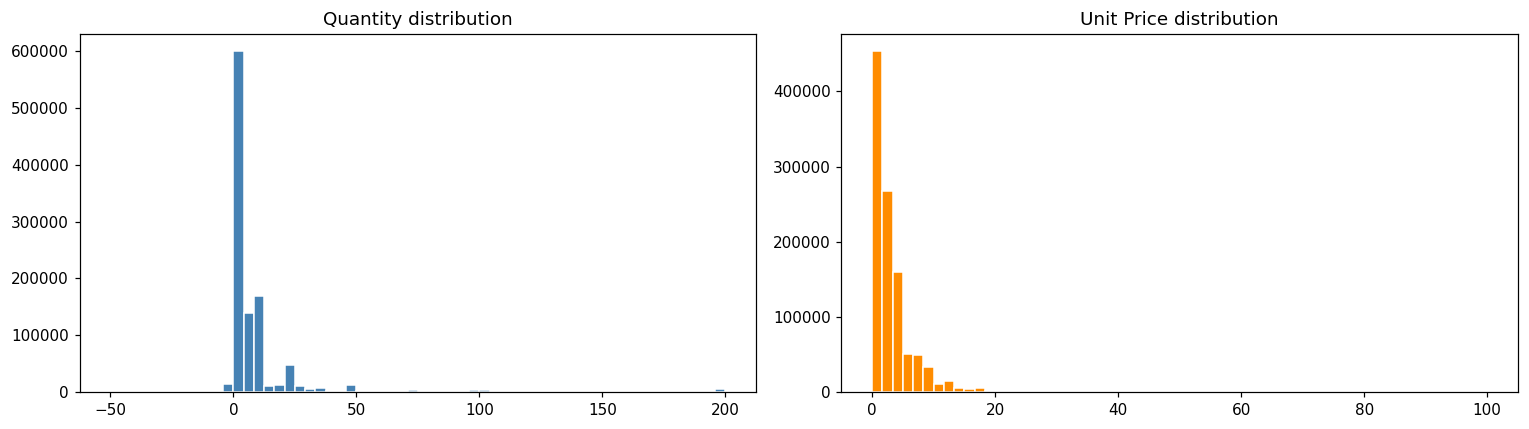

In [4]:
fig, axes = plt.subplots(1,2,figsize=(14,4))
axes[0].hist(df_raw['Quantity'].clip(-50,200), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Quantity distribution')
axes[1].hist(df_raw['Price'].clip(0,100), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Unit Price distribution')
plt.tight_layout(); plt.show()


---
## 2. Preprocessing

In [5]:
df = df_raw.copy()
df = df.dropna(subset=['Customer ID'])
df['Customer ID'] = df['Customer ID'].astype(int)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity']>0)&(df['Price']>0)].drop_duplicates()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year']  = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Revenue']   = df['Quantity'] * df['Price']
print(f"Clean shape: {df.shape}")
df.head()


Clean shape: (779425, 12)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,DayOfWeek,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009,12,1,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009,12,1,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009,12,1,30.0


---
## 3. Feature Engineering

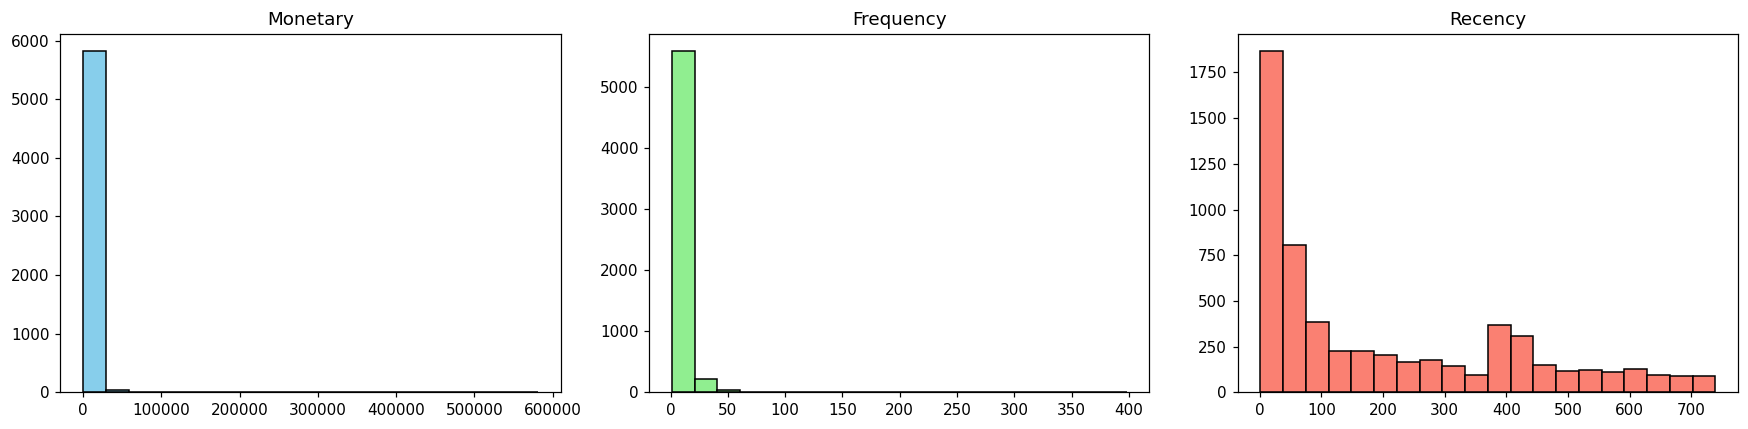

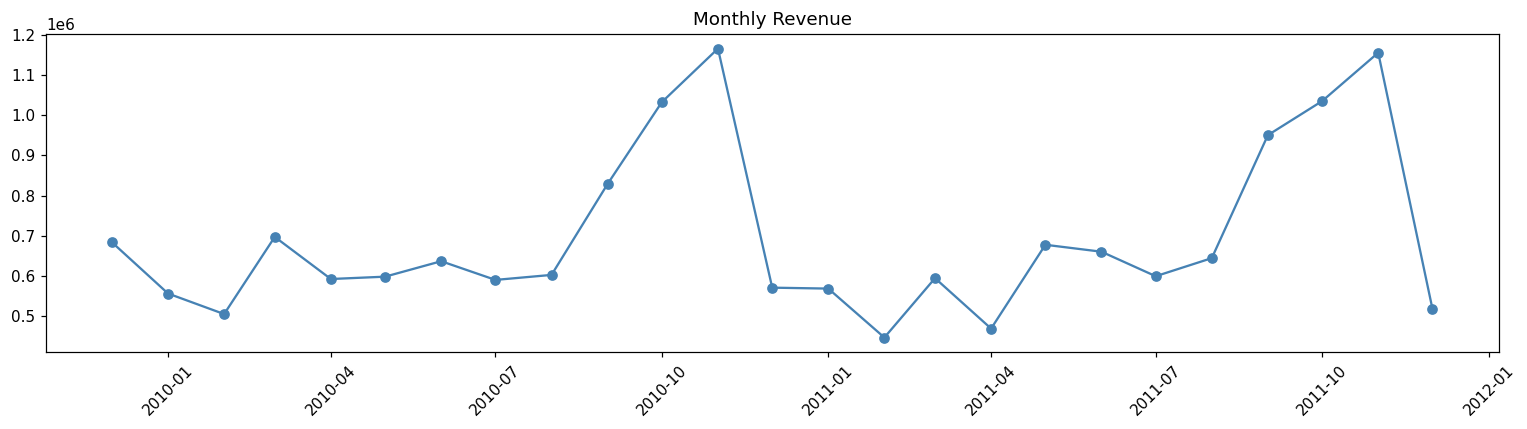

        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    2955.904095
std     1715.572666   209.338707    13.009406   14440.852688
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     342.280000
50%    15314.500000    96.000000     3.000000     867.740000
75%    16797.750000   380.000000     7.000000    2248.305000
max    18287.000000   739.000000   398.000000  580987.040000


In [6]:
REF_DATE = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = (df.groupby('Customer ID')
         .agg(Recency  =('InvoiceDate', lambda x:(REF_DATE-x.max()).days),
              Frequency=('Invoice','nunique'),
              Monetary =('Revenue','sum'))
         .reset_index())

product_stats = (
    df.groupby('StockCode')
      .agg(Description=('Description','first'),
           TotalRevenue=('Revenue','sum'),
           TotalQuantity=('Quantity','sum'),
           AvgPrice=('Price','mean'))
      .reset_index().sort_values('TotalRevenue',ascending=False))

monthly = (df.groupby(['Year','Month'])
             .agg(Revenue=('Revenue','sum'),Orders=('Invoice','nunique'))
             .reset_index().sort_values(['Year','Month']))
monthly['Period'] = pd.to_datetime(
    monthly['Year'].astype(str)+'-'+monthly['Month'].astype(str).str.zfill(2))

fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax,col,c in zip(axes,['Monetary','Frequency','Recency'],['skyblue','lightgreen','salmon']):
    ax.hist(rfm[col],bins=20,color=c,edgecolor='black'); ax.set_title(col)
plt.tight_layout(); plt.show()
plt.figure(figsize=(14,4))
plt.plot(monthly['Period'],monthly['Revenue'],marker='o',color='steelblue')
plt.title('Monthly Revenue'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print(rfm.describe())


---
## 4. Module A — Customer Segmentation

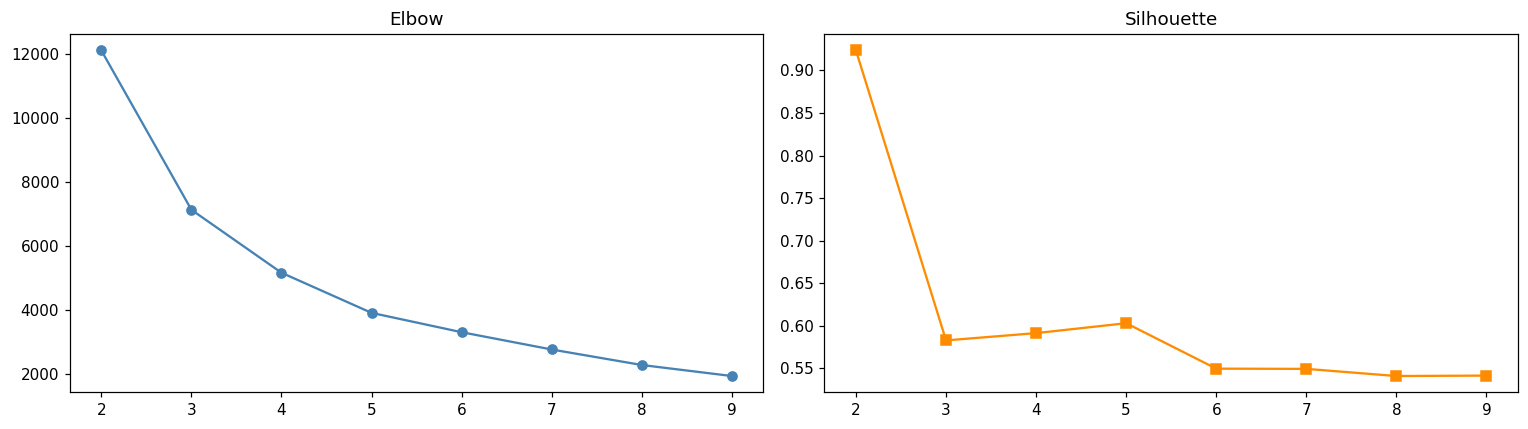

In [7]:
scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm[['Recency','Frequency','Monetary']])

inertias,sils=[],[]
for k in range(2,10):
    km_=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10)
    lbl=km_.fit_predict(rfm_scaled)
    inertias.append(km_.inertia_); sils.append(silhouette_score(rfm_scaled,lbl))
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].plot(range(2,10),inertias,marker='o',color='steelblue'); axes[0].set_title('Elbow')
axes[1].plot(range(2,10),sils,marker='s',color='darkorange');    axes[1].set_title('Silhouette')
plt.tight_layout(); plt.show()


In [8]:
km  = KMeans(n_clusters=N_CLUSTERS,random_state=RANDOM_STATE,n_init=10)
gmm = GaussianMixture(n_components=N_CLUSTERS,random_state=RANDOM_STATE)
db  = DBSCAN(eps=0.5,min_samples=5)

rfm['Cluster_KMeans'] = km.fit_predict(rfm_scaled)
rfm['Cluster_GMM']    = gmm.fit_predict(rfm_scaled)
rfm['Cluster_DBSCAN'] = db.fit_predict(rfm_scaled)

for algo,col in [("KMeans","Cluster_KMeans"),("GMM","Cluster_GMM")]:
    v=rfm[col]!=-1
    print(f"{algo}: Sil={silhouette_score(rfm_scaled[v],rfm.loc[v,col]):.4f}  DBI={davies_bouldin_score(rfm_scaled[v],rfm.loc[v,col]):.4f}")
print(f"DBSCAN noise: {(rfm['Cluster_DBSCAN']==-1).sum()}")

seg_map={}
for rank,(cid,_) in enumerate(
    rfm.groupby('Cluster_KMeans')['Monetary'].mean().sort_values(ascending=False).items()):
    seg_map[cid]=SEGMENT_NAMES[rank]
rfm['Segment']=rfm['Cluster_KMeans'].map(seg_map)
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))


KMeans: Sil=0.6030  DBI=0.6947
GMM: Sil=0.2051  DBI=1.5194
DBSCAN noise: 63
            Recency  Frequency  Monetary
Segment                                 
At-Risk       470.7        2.2     737.2
Loyal          22.5      119.8   98956.8
Occasional     75.3        5.2    1920.6
Potential      25.8       29.5   14171.6
VIP             3.5      212.5  428612.0


---
## 5. Module B — Sales Forecasting (5-fold, 3-month horizon)

In [9]:
ts = monthly[['Period','Revenue']].set_index('Period').sort_index()
for lag in [1,2,3,6]:
    ts[f'lag{lag}'] = ts['Revenue'].shift(lag)
ts['roll3_mean'] = ts['Revenue'].shift(1).rolling(3).mean()
ts['roll3_std']  = ts['Revenue'].shift(1).rolling(3).std()
ts['month_num']  = ts.index.month
ts['year_num']   = ts.index.year
ts = ts.dropna()
FC_FEATS = [c for c in ts.columns if c!='Revenue']
X_ts = ts[FC_FEATS].values; y_ts = ts['Revenue'].values
print(f"Forecasting dataset: {ts.shape} | Folds: {N_TS_SPLITS} | Test size: {TS_TEST_SIZE} months")


Forecasting dataset: (19, 9) | Folds: 5 | Test size: 3 months


In [10]:
tscv = TimeSeriesSplit(n_splits=N_TS_SPLITS, test_size=TS_TEST_SIZE)
fc_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=200,random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200,random_state=RANDOM_STATE),
}
if XGB_AVAILABLE: fc_models['XGBoost']=xgb.XGBRegressor(n_estimators=200,random_state=RANDOM_STATE,verbosity=0)
if LGB_AVAILABLE: fc_models['LightGBM']=lgb.LGBMRegressor(n_estimators=200,random_state=RANDOM_STATE,verbose=-1)

cv_res = {n:{'MAE':[],'RMSE':[],'MAPE':[]} for n in fc_models}
for tr,te in tscv.split(X_ts):
    Xtr=pd.DataFrame(X_ts[tr],columns=FC_FEATS); Xte=pd.DataFrame(X_ts[te],columns=FC_FEATS)
    for name,m in fc_models.items():
        m.fit(Xtr,y_ts[tr]); p=m.predict(Xte); yt=y_ts[te]
        cv_res[name]['MAE'].append(mean_absolute_error(yt,p))
        cv_res[name]['RMSE'].append(np.sqrt(mean_squared_error(yt,p)))
        cv_res[name]['MAPE'].append(np.mean(np.abs((yt-p)/np.maximum(yt,1e-6)))*100)

rows=[]
for n,v in cv_res.items():
    rows.append({'Model':n,'MAE mean':round(np.mean(v['MAE']),2),'MAE std':round(np.std(v['MAE']),2),
                 'RMSE mean':round(np.mean(v['RMSE']),2),'RMSE std':round(np.std(v['RMSE']),2),
                 'MAPE mean':round(np.mean(v['MAPE']),2),'MAPE std':round(np.std(v['MAPE']),2)})
cv_df = pd.DataFrame(rows).set_index('Model')
print(cv_df.to_string())
best_fc_name  = cv_df['RMSE mean'].idxmin()
best_fc_model = fc_models[best_fc_name]
best_fc_model.fit(pd.DataFrame(X_ts[:-TS_TEST_SIZE],columns=FC_FEATS),y_ts[:-TS_TEST_SIZE])
print(f"\nBest forecaster: {best_fc_name}")


                    MAE mean    MAE std  RMSE mean   RMSE std  MAPE mean  MAPE std
Model                                                                             
Linear Regression  434097.57  435642.84  474790.71  428466.09      57.95     50.94
Random Forest      201364.40  116833.58  228014.79  116382.16      29.48     20.24
Gradient Boosting  242288.39  188174.67  272615.66  193611.65      36.44     37.18
XGBoost            238193.84  156630.10  269851.58  168059.50      36.51     29.82
LightGBM           224012.29   94434.38  252934.03   92221.07      30.09     11.11

Best forecaster: Random Forest


---
## 6. Module C — Anomaly Detection

IsolationForest anomalies: 15541 (1.99%)
LOF anomalies (sample=50000): 998


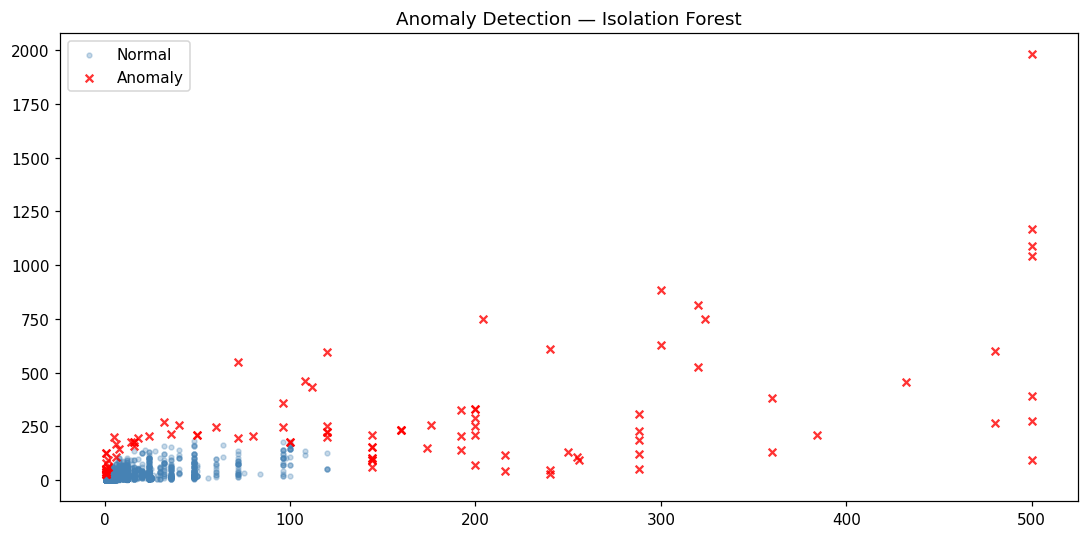

In [11]:
anom_sc = StandardScaler()
X_anom  = anom_sc.fit_transform(df[['Quantity','Price','Revenue']])
iso = IsolationForest(contamination=0.02,random_state=RANDOM_STATE,n_jobs=1)
df['Anomaly'] = iso.fit_predict(X_anom)
n_iso = (df['Anomaly']==-1).sum()
print(f"IsolationForest anomalies: {n_iso} ({n_iso/len(df)*100:.2f}%)")
SAMP=min(50_000,len(X_anom))
idx_s=np.random.choice(len(X_anom),SAMP,replace=False)
lof=LocalOutlierFactor(n_neighbors=20,contamination=0.02,n_jobs=1)
lof_l=lof.fit_predict(X_anom[idx_s])
print(f"LOF anomalies (sample={SAMP}): {(lof_l==-1).sum()}")

spl=df[['Quantity','Revenue','Anomaly']].sample(5000,random_state=RANDOM_STATE)
norm,anom_=spl[spl['Anomaly']==1],spl[spl['Anomaly']==-1]
plt.figure(figsize=(10,5))
plt.scatter(norm['Quantity'].clip(-50,500), norm['Revenue'].clip(0,5000), alpha=0.3,s=10,label='Normal',color='steelblue')
plt.scatter(anom_['Quantity'].clip(-50,500),anom_['Revenue'].clip(0,5000),alpha=0.8,s=25,label='Anomaly',color='red',marker='x')
plt.title('Anomaly Detection — Isolation Forest'); plt.legend(); plt.tight_layout(); plt.show()


---
## 7. Module D — SmartViz-ML

### 7a. Meta-Feature Profiles & Rule-Based Baseline

In [12]:
META_PROFILES = {
    "temporal_num":  dict(n_numeric=2,n_categorical=0,n_datetime=1,max_cardinality=0, mean_correlation=0.4,missing_ratio=0.01,has_temporal=1,has_geo=0),
    "temporal_cat":  dict(n_numeric=1,n_categorical=2,n_datetime=1,max_cardinality=8, mean_correlation=0.2,missing_ratio=0.02,has_temporal=1,has_geo=0),
    "cat_num":       dict(n_numeric=1,n_categorical=1,n_datetime=0,max_cardinality=12,mean_correlation=0.1,missing_ratio=0.02,has_temporal=0,has_geo=0),
    "cat_prop":      dict(n_numeric=1,n_categorical=1,n_datetime=0,max_cardinality=5, mean_correlation=0.05,missing_ratio=0.0,has_temporal=0,has_geo=0),
    "cat_prop_many": dict(n_numeric=1,n_categorical=1,n_datetime=0,max_cardinality=25,mean_correlation=0.05,missing_ratio=0.0,has_temporal=0,has_geo=0),
    "num_dist":      dict(n_numeric=1,n_categorical=0,n_datetime=0,max_cardinality=0, mean_correlation=0.0,missing_ratio=0.03,has_temporal=0,has_geo=0),
    "num_dist_multi":dict(n_numeric=1,n_categorical=1,n_datetime=0,max_cardinality=4, mean_correlation=0.15,missing_ratio=0.02,has_temporal=0,has_geo=0),
    "num_num":       dict(n_numeric=2,n_categorical=0,n_datetime=0,max_cardinality=0, mean_correlation=0.65,missing_ratio=0.01,has_temporal=0,has_geo=0),
    "num_num_multi": dict(n_numeric=5,n_categorical=0,n_datetime=0,max_cardinality=0, mean_correlation=0.55,missing_ratio=0.02,has_temporal=0,has_geo=0),
    "geo_num":       dict(n_numeric=1,n_categorical=1,n_datetime=0,max_cardinality=40,mean_correlation=0.1,missing_ratio=0.05,has_temporal=0,has_geo=1),
    "cluster_cat":   dict(n_numeric=1,n_categorical=2,n_datetime=0,max_cardinality=6, mean_correlation=0.2,missing_ratio=0.01,has_temporal=0,has_geo=0),
    "cluster_num":   dict(n_numeric=3,n_categorical=1,n_datetime=0,max_cardinality=5, mean_correlation=0.3,missing_ratio=0.01,has_temporal=0,has_geo=0),
    "num_anom":      dict(n_numeric=2,n_categorical=0,n_datetime=0,max_cardinality=0, mean_correlation=0.4,missing_ratio=0.04,has_temporal=0,has_geo=0),
    "cat_rank":      dict(n_numeric=1,n_categorical=1,n_datetime=0,max_cardinality=15,mean_correlation=0.05,missing_ratio=0.0,has_temporal=0,has_geo=0),
}

KEYWORD_MAP = {
    r'trend|over time|evolution|monthly|weekly|daily|forecast': ['line_chart'],
    r'top|best|worst|rank|most|least|leading':                  ['bar_chart'],
    r'correlation|relationship|versus|vs\b|link|associate':     ['scatter_plot','heatmap'],
    r'proportion|share|percentage|part|breakdown':              ['pie_chart','bar_chart'],
    r'distribution|spread|range|quartile|outlier|skew':         ['histogram','box_plot'],
    r'segment|cluster|group|profile':                           ['bar_chart','scatter_plot'],
    r'map|region|country|geographic|location':                  ['choropleth'],
    r'anomal|unusual|suspicious|extreme|abnormal':              ['scatter_plot','box_plot'],
    r'matrix|pairwise|all variables|overview':                  ['heatmap'],
}

def rule_rank(meta, query):
    scores = {v:0.0 for v in VIZ_TYPES}
    q=query.lower()
    if meta.get('has_temporal',0): scores['line_chart']  +=3.0
    if meta.get('has_geo',0):      scores['choropleth']  +=3.5
    nn,nc,corr,card=meta.get('n_numeric',0),meta.get('n_categorical',0),meta.get('mean_correlation',0),meta.get('max_cardinality',0)
    if nn>=5:                      scores['heatmap']      +=2.5
    if nn>=2:                      scores['scatter_plot'] +=2.0+corr; scores['heatmap']+=1.5
    if nn==1 and nc==0:            scores['histogram']    +=2.0; scores['box_plot']+=1.5
    if nc>=1 and nn>=1:            scores['bar_chart']    +=2.5
    if card<=6 and nc>=1:          scores['pie_chart']    +=1.0
    if card>10:                    scores['pie_chart']    -=2.5
    for pat,charts in KEYWORD_MAP.items():
        if re.search(pat,q):
            for ch in charts: scores[ch]+=2.0
    return sorted(VIZ_TYPES,key=lambda v:scores[v],reverse=True)

def rule_predict(xr, query):
    return rule_rank(dict(zip(FEATURE_COLS,xr[0])),query)

print("Meta-profiles and rule baseline defined.")


Meta-profiles and rule baseline defined.


### 7b. Pool A & B Construction

In [13]:
SEED_RULES = [
    ("temporal_num", "trend over time monthly weekly evolution forecast",     "line_chart",   False),
    ("temporal_num", "sales revenue growth decline prediction",               "line_chart",   False),
    ("temporal_cat", "category performance comparison trend",                 "line_chart",   True),
    ("cat_num",      "top best worst rank compare most least",                "bar_chart",    False),
    ("cat_num",      "revenue category product country segment",              "bar_chart",    False),
    ("cat_num",      "average mean median per group",                         "bar_chart",    True),
    ("cat_prop",     "proportion share percentage breakdown contribution",    "pie_chart",    True),
    ("cat_prop_many","proportion share percentage many categories",           "bar_chart",    True),
    ("num_dist",     "distribution spread range histogram frequency",         "histogram",    False),
    ("num_dist",     "quartile median outlier interquartile whisker",         "box_plot",     False),
    ("num_dist_multi","distribution compare groups spread variability",       "box_plot",     True),
    ("num_num",      "correlation relationship two variables scatter",        "scatter_plot", False),
    ("num_num_multi","correlation matrix all variables heatmap",              "heatmap",      False),
    ("num_num",      "versus relationship link association",                  "scatter_plot", True),
    ("geo_num",      "map region country geographic location",                "choropleth",   False),
    ("geo_num",      "sales country revenue geographic distribution",         "choropleth",   True),
    ("cluster_cat",  "segment cluster group customer profile",                "bar_chart",    True),
    ("cluster_num",  "segment scatter rfm recency frequency monetary",        "scatter_plot", True),
    ("num_anom",     "anomaly outlier unusual suspicious extreme",            "scatter_plot", True),
    ("cat_rank",     "ranking leaderboard top bottom sorted",                 "bar_chart",    False),
]
NOISE = {'n_numeric':(0,1),'n_categorical':(0,1),'n_datetime':(0,0),'max_cardinality':(0,5),
         'mean_correlation':(-0.05,0.05),'missing_ratio':(-0.005,0.005),'has_temporal':(0,0),'has_geo':(0,0)}

np.random.seed(RANDOM_STATE)
pool_A_rows,pool_B_rows=[],[]
for pk,intent_str,viz,ambig in SEED_RULES:
    prof  = META_PROFILES.get(pk,META_PROFILES['cat_num'])
    words = intent_str.split()
    for pool_rows,n_var in [(pool_A_rows,12 if not ambig else 8),(pool_B_rows,4)]:
        for _ in range(n_var):
            np.random.shuffle(words)
            q = ' '.join(words[:min(5,len(words))])
            pert={}
            for feat,(lo,hi) in NOISE.items():
                base=prof[feat]
                if isinstance(base,float): pert[feat]=float(np.clip(base+np.random.uniform(lo,hi),0,1))
                else:                      pert[feat]=int(max(0,base+np.random.randint(lo,hi+1)))
            pool_rows.append({'query':q,'primary_viz':viz,'ambiguous':ambig,**pert,**encode_query(q)})

pool_A=pd.DataFrame(pool_A_rows); pool_B=pd.DataFrame(pool_B_rows)
print(f"Pool A: {len(pool_A)}  Pool B: {len(pool_B)}")


Pool A: 200  Pool B: 80


### 7c. Pool C — Independent Test Set (Explicit domain column)
> Each item carries `domain` assigned at construction time — **never inferred post-hoc**.


In [14]:
POOL_C_ITEMS = [['temporal_num', 'Show how total sales changed quarter by quarter', 'line_chart', False, 'Retail'], ['temporal_num', 'Is there a seasonal pattern in weekly order volumes?', 'line_chart', False, 'Retail'], ['temporal_num', 'How did customer acquisition change after Q3 campaign?', 'line_chart', True, 'Retail'], ['temporal_cat', 'Compare sales trajectory of our three product lines', 'line_chart', True, 'Retail'], ['temporal_num', 'Did revenue recover after the supply disruption in March?', 'line_chart', False, 'Retail'], ['temporal_num', 'Track monthly active customer count over the past year', 'line_chart', False, 'Retail'], ['temporal_num', 'How have non-performing loans changed over eight quarters?', 'line_chart', False, 'Banking'], ['temporal_num', 'Plot daily transaction volume for past three months', 'line_chart', False, 'Banking'], ['temporal_cat', 'Compare deposit growth across three branch networks', 'line_chart', True, 'Banking'], ['temporal_num', 'How has monthly patient admission count changed this year?', 'line_chart', False, 'Healthcare'], ['temporal_num', 'Show the readmission rate over past 24 months', 'line_chart', False, 'Healthcare'], ['temporal_cat', 'Compare ICU occupancy across three hospital sites over time', 'line_chart', True, 'Healthcare'], ['temporal_num', 'Track production output week by week for last quarter', 'line_chart', False, 'Manufacturing'], ['temporal_num', 'How has machine downtime changed since the maintenance overhaul?', 'line_chart', False, 'Manufacturing'], ['temporal_num', 'Show employee headcount changes each month this year', 'line_chart', False, 'HR'], ['temporal_num', 'How has voluntary turnover evolved over the past two years?', 'line_chart', False, 'HR'], ['cat_rank', 'Which five countries generated the most orders last year?', 'bar_chart', False, 'Retail'], ['cat_num', 'What are the ten highest-grossing product categories?', 'bar_chart', False, 'Retail'], ['cat_num', 'How do average order values differ across customer tiers?', 'bar_chart', True, 'Retail'], ['cat_rank', 'Give a performance leaderboard for our product lines', 'bar_chart', False, 'Retail'], ['cluster_cat', 'How many customers fall into each loyalty segment?', 'bar_chart', True, 'Retail'], ['cat_prop_many', 'Show revenue contribution of every product subcategory', 'bar_chart', False, 'Retail'], ['cat_num', 'Which branch offices have the highest loan default rate?', 'bar_chart', False, 'Banking'], ['cat_rank', 'Rank mortgage products by total outstanding balance', 'bar_chart', False, 'Banking'], ['cat_num', 'Which departments have the longest average patient wait times?', 'bar_chart', False, 'Healthcare'], ['cat_rank', 'What are the ten most frequently prescribed medications?', 'bar_chart', False, 'Healthcare'], ['cat_num', 'Which production line has the highest scrap rate?', 'bar_chart', False, 'Manufacturing'], ['cat_rank', 'Rank suppliers by on-time delivery performance', 'bar_chart', False, 'Manufacturing'], ['cat_num', 'Which department has the highest absenteeism rate?', 'bar_chart', False, 'HR'], ['cat_rank', 'Rank job functions by average time-to-fill', 'bar_chart', False, 'HR'], ['cluster_cat', 'Break down workforce by performance rating tier', 'bar_chart', True, 'HR'], ['num_num', 'Do frequent customers also spend more per visit?', 'scatter_plot', False, 'Retail'], ['num_num', 'Is there a link between product price and quantity ordered?', 'scatter_plot', False, 'Retail'], ['cluster_num', 'Plot customers by recency and total spend to spot groups', 'scatter_plot', True, 'Retail'], ['num_anom', 'Flag transactions that look very different from typical orders', 'scatter_plot', True, 'Retail'], ['cluster_num', 'Visualise the RFM space to identify natural clusters', 'scatter_plot', False, 'Retail'], ['num_num', 'Is there a relationship between loan amount and default probability?', 'scatter_plot', False, 'Banking'], ['num_anom', 'Show transactions that deviate from normal spending patterns', 'scatter_plot', True, 'Banking'], ['num_num', 'Does length of stay correlate with total treatment cost?', 'scatter_plot', False, 'Healthcare'], ['cluster_num', 'Cluster patients by diagnosis frequency and average stay', 'scatter_plot', True, 'Healthcare'], ['num_num', 'Does machine temperature correlate with defect rate?', 'scatter_plot', False, 'Manufacturing'], ['num_anom', 'Which production batches fall outside normal quality parameters?', 'scatter_plot', True, 'Manufacturing'], ['num_num', 'Does years of experience correlate with performance score?', 'scatter_plot', False, 'HR'], ['cluster_num', 'Segment employees by tenure and income', 'scatter_plot', True, 'HR'], ['cat_prop', 'What fraction of revenue comes from repeat versus new buyers?', 'pie_chart', True, 'Retail'], ['cat_prop', 'What share of orders are returned versus fulfilled?', 'pie_chart', True, 'Retail'], ['cat_prop', 'What proportion of our loan book is in each risk grade?', 'pie_chart', True, 'Banking'], ['cat_prop', 'How is revenue split between retail and corporate clients?', 'pie_chart', True, 'Banking'], ['cat_prop', 'What share of admissions are planned versus emergency?', 'pie_chart', True, 'Healthcare'], ['cat_prop', 'Break down diagnosis categories by admission volume', 'pie_chart', True, 'Healthcare'], ['cat_prop', 'What fraction of defects fall into each defect type?', 'pie_chart', True, 'Manufacturing'], ['cat_prop', 'Show the cost breakdown across materials, labour, overhead', 'pie_chart', True, 'Manufacturing'], ['cat_prop', 'What share of workforce is in each employment contract type?', 'pie_chart', True, 'HR'], ['cat_prop', 'Break down voluntary exits by stated reason', 'pie_chart', True, 'HR'], ['num_dist', 'What does the distribution of individual order values look like?', 'histogram', False, 'Retail'], ['num_dist', 'How spread out are customer lifetime values?', 'histogram', True, 'Retail'], ['num_dist', 'Show the full range of unit prices across our catalogue', 'histogram', False, 'Retail'], ['num_dist', 'Show distribution of approved loan amounts', 'histogram', False, 'Banking'], ['num_dist', 'How are customer credit scores distributed?', 'histogram', False, 'Banking'], ['num_dist', 'What does the distribution of patient ages look like?', 'histogram', False, 'Healthcare'], ['num_dist', 'Show distribution of total billing amounts per patient', 'histogram', False, 'Healthcare'], ['num_dist', 'Show distribution of cycle times on the assembly line', 'histogram', False, 'Manufacturing'], ['num_dist', 'What is the distribution of defects per batch?', 'histogram', False, 'Manufacturing'], ['num_dist', 'What does the salary distribution look like across the company?', 'histogram', False, 'HR'], ['num_dist', 'How are employee performance scores distributed?', 'histogram', False, 'HR'], ['num_dist', 'Summarise variability in delivery lead times', 'box_plot', False, 'Retail'], ['num_dist_multi', 'Compare purchase-frequency distributions across segments', 'box_plot', True, 'Retail'], ['num_anom', 'Are there products with abnormally high return-to-sale ratios?', 'box_plot', True, 'Retail'], ['num_dist', 'Show the spread of loan interest rates across product types', 'box_plot', False, 'Banking'], ['num_dist_multi', 'Compare transaction amount variability across customer segments', 'box_plot', True, 'Banking'], ['num_dist', 'Summarise spread of patient stay durations', 'box_plot', False, 'Healthcare'], ['num_dist_multi', 'Compare treatment cost variability across diagnosis groups', 'box_plot', True, 'Healthcare'], ['num_dist', 'Show variability in daily output across production shifts', 'box_plot', False, 'Manufacturing'], ['num_dist_multi', 'Compare defect rate spread across production lines', 'box_plot', True, 'Manufacturing'], ['num_dist', 'Show spread of performance scores within each department', 'box_plot', False, 'HR'], ['num_dist_multi', 'Compare salary variability across job grades', 'box_plot', True, 'HR'], ['num_num_multi', 'Give overview of how all KPIs relate to each other', 'heatmap', False, 'Retail'], ['num_num_multi', 'Display pairwise correlations for all RFM dimensions', 'heatmap', False, 'Retail'], ['num_num_multi', 'Show pairwise correlations across all credit risk indicators', 'heatmap', False, 'Banking'], ['num_num_multi', 'Which financial ratios relate most to default risk?', 'heatmap', True, 'Banking'], ['num_num_multi', 'Correlate all clinical outcome metrics', 'heatmap', False, 'Healthcare'], ['num_num_multi', 'Show correlations between all process quality parameters', 'heatmap', False, 'Manufacturing'], ['num_num_multi', 'Which production metrics are most interdependent?', 'heatmap', True, 'Manufacturing'], ['num_num_multi', 'Show how engagement, performance and tenure relate', 'heatmap', False, 'HR'], ['geo_num', 'Show total revenue by country on a world map', 'choropleth', False, 'Retail'], ['geo_num', 'Which European markets are underperforming?', 'choropleth', True, 'Retail'], ['geo_num', 'Map out where highest-value customers are based', 'choropleth', False, 'Retail'], ['geo_num', 'Show default rates by country for international loan book', 'choropleth', False, 'Banking'], ['geo_num', 'Map branch profitability across regions', 'choropleth', False, 'Banking'], ['geo_num', 'Map disease incidence rates by region', 'choropleth', False, 'Healthcare'], ['geo_num', 'Show hospital bed availability across provinces', 'choropleth', False, 'Healthcare'], ['geo_num', 'Show supplier network on map weighted by delivery volume', 'choropleth', False, 'Manufacturing'], ['geo_num', 'Which regions have the highest logistics cost per unit?', 'choropleth', True, 'Manufacturing'], ['geo_num', 'Map headcount by office location', 'choropleth', False, 'HR'], ['geo_num', 'Show attrition rate by country across global offices', 'choropleth', True, 'HR'], ['temporal_num', 'How did our refund rate change quarter by quarter?', 'line_chart', False, 'Retail'], ['temporal_num', 'Plot daily active users over the past six months', 'line_chart', False, 'Retail'], ['temporal_num', 'Show the monthly churn rate since product launch', 'line_chart', False, 'Retail'], ['cat_num', 'How does average response time differ across support channels?', 'bar_chart', True, 'Retail'], ['cat_rank', 'Which regions closed the most deals last quarter?', 'bar_chart', False, 'Retail'], ['num_num', 'Does campaign spend correlate with new customer acquisitions?', 'scatter_plot', False, 'Retail'], ['num_num', 'Is there a link between employee tenure and performance rating?', 'scatter_plot', False, 'HR'], ['cat_prop', 'What share of support tickets are resolved on first contact?', 'pie_chart', True, 'Retail'], ['num_dist', 'What does the distribution of customer age look like?', 'histogram', False, 'Retail'], ['num_dist', 'Show distribution of days between repeat purchases', 'histogram', False, 'Retail'], ['num_dist', 'Show the spread of contract renewal values', 'box_plot', False, 'Retail'], ['num_dist_multi', 'Compare revenue variability across our four regions', 'box_plot', True, 'Retail'], ['num_num_multi', 'Show correlations between all operational efficiency metrics', 'heatmap', False, 'Retail'], ['num_num_multi', 'Which customer behaviour metrics co-vary most strongly?', 'heatmap', True, 'Retail'], ['geo_num', 'Show customer density by postal district', 'choropleth', False, 'Retail'], ['geo_num', 'Map warranty claim rates across countries', 'choropleth', True, 'Retail'], ['temporal_num', 'Plot the monthly volume of escalated support tickets', 'line_chart', False, 'Retail'], ['cat_num', 'Compare average handle time across contact centre teams', 'bar_chart', True, 'Retail'], ['num_num', 'Does product complexity predict defect rate?', 'scatter_plot', False, 'Manufacturing'], ['cat_prop', 'What fraction of our budget goes to each cost centre?', 'pie_chart', True, 'Retail'], ['num_dist', 'What is the spread of customer onboarding durations?', 'histogram', False, 'Retail'], ['num_dist_multi', 'Compare churn rate variability across acquisition cohorts', 'box_plot', True, 'Retail'], ['num_num_multi', 'Show pairwise correlations for all revenue-driver metrics', 'heatmap', False, 'Retail'], ['geo_num', 'Map digital adoption rates by country', 'choropleth', True, 'Retail'], ['temporal_num', 'Track net promoter score changes over the past year', 'line_chart', False, 'Retail'], ['temporal_num', 'How has average order fulfilment time evolved this year?', 'line_chart', False, 'Retail'], ['cat_rank', 'Which three product families drive the most complaints?', 'bar_chart', False, 'Retail'], ['cat_num', 'Which product categories have the highest return rate?', 'bar_chart', False, 'Retail'], ['num_num', 'Does marketing spend predict next-month new customer count?', 'scatter_plot', False, 'Retail'], ['num_anom', 'Which customer accounts show unusual transaction patterns?', 'scatter_plot', True, 'Retail'], ['cat_prop', 'How is our marketing budget allocated across channels?', 'pie_chart', True, 'Retail'], ['cat_prop', 'Break down customer complaints by root cause category', 'pie_chart', True, 'Retail'], ['num_dist', 'How are product review scores distributed?', 'histogram', False, 'Retail'], ['num_dist', 'Show distribution of time-to-close for sales opportunities', 'histogram', False, 'Retail'], ['num_dist', 'Are there outliers in time-to-hire across recruiting channels?', 'box_plot', True, 'HR'], ['num_dist_multi', 'Compare bonus variability across seniority levels', 'box_plot', True, 'HR'], ['num_num_multi', 'Show pairwise correlations for all customer lifetime value drivers', 'heatmap', False, 'Retail'], ['num_num_multi', 'Which quality control metrics are most strongly linked?', 'heatmap', True, 'Manufacturing'], ['geo_num', 'Show our market share by country on a world map', 'choropleth', False, 'Retail'], ['geo_num', 'Which regions have the highest rate of product returns?', 'choropleth', True, 'Retail'], ['temporal_num', 'Did average delivery time improve after the carrier switch?', 'line_chart', True, 'Retail'], ['cat_rank', 'Rank our ten best-selling SKUs by unit volume', 'bar_chart', False, 'Retail'], ['num_num', 'Does discount depth correlate with repeat purchase rate?', 'scatter_plot', True, 'Retail'], ['cluster_num', 'Segment stores by footfall and average basket value', 'scatter_plot', True, 'Retail'], ['cat_prop', 'What proportion of invoices are paid on time vs late?', 'pie_chart', True, 'Retail'], ['num_dist', 'Show distribution of session durations on our app', 'histogram', False, 'Retail'], ['num_dist', 'How are employee satisfaction scores distributed?', 'histogram', False, 'HR'], ['num_dist', 'What does the distribution of claim amounts look like?', 'histogram', False, 'Banking'], ['num_dist_multi', 'Compare defect rate variability across our three factories', 'box_plot', True, 'Manufacturing'], ['num_dist', 'Are there outliers in time-to-first-response by support tier?', 'box_plot', True, 'Retail'], ['num_num_multi', 'Correlate all patient risk factors with each other', 'heatmap', False, 'Healthcare'], ['num_num_multi', 'Show how all HR metrics relate to employee retention', 'heatmap', True, 'HR'], ['geo_num', 'Map average property loan size by region', 'choropleth', False, 'Banking'], ['geo_num', 'Show disease prevalence rates by province', 'choropleth', False, 'Healthcare'], ['temporal_num', 'Plot monthly carbon emissions since the sustainability programme', 'line_chart', False, 'Manufacturing'], ['temporal_num', 'How has the ratio of digital to in-store sales shifted?', 'line_chart', True, 'Retail'], ['temporal_num', 'Show the quarterly evolution of our net promoter score', 'line_chart', False, 'Retail'], ['temporal_cat', 'Compare loan approval rates across three product lines over time', 'line_chart', True, 'Banking'], ['temporal_num', 'How has overnight ICU occupancy changed across the year?', 'line_chart', False, 'Healthcare'], ['temporal_num', 'Track the weekly volume of parts rejected on the assembly line', 'line_chart', False, 'Manufacturing'], ['temporal_num', 'Plot monthly revenue per employee over the last two years', 'line_chart', True, 'Retail'], ['temporal_num', 'How has electricity consumption changed over 12 months?', 'line_chart', False, 'Manufacturing'], ['temporal_num', 'Track inventory turnover rate month by month', 'line_chart', False, 'Retail'], ['temporal_cat', 'Compare revenue trends across our four sales channels', 'line_chart', True, 'Retail'], ['temporal_num', 'Show how customer satisfaction scores evolved after the merger', 'line_chart', False, 'Retail'], ['temporal_num', 'Show the net interest margin trajectory since 2020', 'line_chart', False, 'Banking'], ['temporal_num', 'Plot the defect rate per shift over the last six months', 'line_chart', False, 'Manufacturing'], ['temporal_num', 'How has the share of mobile orders grown over two years?', 'line_chart', False, 'Retail'], ['temporal_num', 'Track weekly website conversion rate over the past six months', 'line_chart', False, 'Retail'], ['cat_num', 'How does average session duration differ across device types?', 'bar_chart', True, 'Retail'], ['cat_rank', 'What are the top ten customer complaints by frequency?', 'bar_chart', False, 'Retail'], ['cat_num', 'Which distribution centres have the highest mis-pick rate?', 'bar_chart', False, 'Retail'], ['cat_num', 'Compare energy consumption across our three plants', 'bar_chart', True, 'Manufacturing'], ['cat_num', 'Which wards have the highest nurse-to-patient ratio?', 'bar_chart', True, 'Healthcare'], ['cat_num', 'Compare mean time between failures across our five machines', 'bar_chart', False, 'Manufacturing'], ['cluster_cat', 'Show the count of employees in each engagement tier', 'bar_chart', True, 'HR'], ['cat_prop_many', 'Display gross margin contribution by product family', 'bar_chart', False, 'Retail'], ['cat_num', 'Which marketing campaigns generated the most leads?', 'bar_chart', False, 'Retail'], ['cat_num', 'Compare average customer acquisition cost across channels', 'bar_chart', True, 'Retail'], ['cat_num', 'Which product lines have the lowest gross margin?', 'bar_chart', False, 'Retail'], ['cat_rank', 'Which five markets have the highest churn rate?', 'bar_chart', False, 'Retail'], ['cluster_cat', 'How many accounts fall into each credit risk category?', 'bar_chart', True, 'Banking'], ['cat_num', 'Which job roles have the longest average time-to-productivity?', 'bar_chart', False, 'HR'], ['cat_num', 'Compare customer retention rates across acquisition channels?', 'bar_chart', True, 'Retail'], ['num_num', 'Does campaign spend correlate with conversion rate?', 'scatter_plot', False, 'Retail'], ['num_num', 'Is there a link between commute time and job satisfaction?', 'scatter_plot', True, 'HR'], ['cluster_num', 'Group suppliers by delivery reliability and cost per unit', 'scatter_plot', True, 'Manufacturing'], ['num_num', 'Is there a relationship between ad impressions and click-through rate?', 'scatter_plot', False, 'Retail'], ['num_num', 'Does time-on-page correlate with conversion probability?', 'scatter_plot', False, 'Retail'], ['num_num', 'Is there a relationship between product weight and shipping cost?', 'scatter_plot', False, 'Retail'], ['cluster_num', 'Plot branches by deposit volume and loan-to-deposit ratio', 'scatter_plot', True, 'Banking'], ['num_num', 'Does onboarding duration predict 90-day retention?', 'scatter_plot', False, 'Retail'], ['num_num', 'Do higher-income customers hold larger deposit balances?', 'scatter_plot', False, 'Banking'], ['num_anom', 'Flag patients whose length of stay is unusually high for diagnosis', 'scatter_plot', True, 'Healthcare'], ['num_num', 'Does energy consumption correlate with units produced per shift?', 'scatter_plot', False, 'Manufacturing'], ['cluster_num', 'Segment products by return rate and gross margin', 'scatter_plot', True, 'Retail'], ['cat_prop', 'What share of our energy use comes from renewable sources?', 'pie_chart', True, 'Manufacturing'], ['cat_prop', 'Break down project hours by phase for the last delivery', 'pie_chart', True, 'Retail'], ['cat_prop', 'What fraction of our SKUs account for 80% of sales volume?', 'pie_chart', True, 'Retail'], ['cat_prop', 'How is our headcount split across business functions?', 'pie_chart', True, 'HR'], ['cat_prop', 'What proportion of patients are admitted via each pathway?', 'pie_chart', True, 'Healthcare'], ['cat_prop', 'Break down loan defaults by borrower industry', 'pie_chart', True, 'Banking'], ['cat_prop', 'What proportion of defects are caught at each inspection stage?', 'pie_chart', True, 'Manufacturing'], ['cat_prop', 'Give a breakdown of staff headcount by employment type', 'pie_chart', True, 'HR'], ['num_dist', 'What does the distribution of customer tenure in months look like?', 'histogram', False, 'Retail'], ['num_dist', 'How are loan-to-value ratios distributed?', 'histogram', False, 'Banking'], ['num_dist', 'How are surgical procedure durations distributed?', 'histogram', False, 'Healthcare'], ['num_dist', 'Show the distribution of energy consumption per production run', 'histogram', False, 'Manufacturing'], ['num_dist', 'What is the spread of employee commute distances?', 'histogram', False, 'HR'], ['num_dist', 'Show the distribution of invoice payment lead times', 'histogram', False, 'Retail'], ['num_dist', 'What does the distribution of project team sizes look like?', 'histogram', False, 'Retail'], ['num_dist', 'How are time-since-last-promotion values distributed?', 'histogram', False, 'HR'], ['num_dist', 'Show the distribution of batch sizes on the production line', 'histogram', False, 'Manufacturing'], ['num_dist', 'How are patient wait times distributed across clinics?', 'histogram', False, 'Healthcare'], ['num_dist', 'Show the spread of delivery times across logistics providers', 'box_plot', False, 'Retail'], ['num_dist_multi', 'Compare revenue variability across our four sales regions', 'box_plot', True, 'Retail'], ['num_dist', 'Are there outliers in the distribution of call handling times?', 'box_plot', True, 'Retail'], ['num_dist_multi', 'Compare recovery time distributions across hospital wards', 'box_plot', True, 'Healthcare'], ['num_dist_multi', 'Compare machine cycle-time spread across production lines', 'box_plot', True, 'Manufacturing'], ['num_dist', 'Are there outlying batches in terms of cycle time?', 'box_plot', True, 'Manufacturing'], ['num_dist', 'Show the spread of gross margins across product lines', 'box_plot', False, 'Retail'], ['num_dist_multi', 'Compare sales cycle length across industry verticals', 'box_plot', True, 'Retail'], ['num_dist', 'Show variability in daily call centre volume', 'box_plot', False, 'Retail'], ['num_dist', 'Are there outliers in weekly call-centre abandonment rates?', 'box_plot', True, 'Retail'], ['num_num_multi', 'Display pairwise correlations for all supply-chain KPIs', 'heatmap', False, 'Retail'], ['num_num_multi', 'Show how all employee engagement dimensions relate', 'heatmap', True, 'HR'], ['num_num_multi', 'Correlate all financial ratios for our top 20 customers', 'heatmap', False, 'Banking'], ['num_num_multi', 'Which product attributes are most correlated with return rate?', 'heatmap', True, 'Retail'], ['num_num_multi', 'Show correlations between patient outcome metrics', 'heatmap', False, 'Healthcare'], ['num_num_multi', 'Which process parameters are most interdependent in our plant?', 'heatmap', True, 'Manufacturing'], ['num_num_multi', 'Show how all engagement and performance metrics relate', 'heatmap', True, 'HR'], ['num_num_multi', 'Which loan portfolio metrics co-vary most strongly?', 'heatmap', True, 'Banking'], ['geo_num', 'Which cities have the highest app download rates?', 'choropleth', False, 'Retail'], ['geo_num', 'Show average delivery time by destination country', 'choropleth', False, 'Retail'], ['geo_num', 'Map employee headcount by office location globally', 'choropleth', False, 'HR'], ['geo_num', 'Which provinces have the highest insurance claim frequency?', 'choropleth', True, 'Banking'], ['geo_num', 'Show per-capita energy consumption by region', 'choropleth', False, 'Manufacturing'], ['geo_num', 'Map the geographic spread of supply chain disruptions', 'choropleth', True, 'Manufacturing'], ['geo_num', 'Show revenue per capita across our sales territories', 'choropleth', False, 'Retail'], ['geo_num', 'Map average employee salary by office country', 'choropleth', True, 'HR'], ['geo_num', 'Which regions have the lowest vaccination coverage?', 'choropleth', True, 'Healthcare'], ['geo_num', 'Show which territories have the most underserved segments', 'choropleth', True, 'Retail'], ['temporal_num', 'Plot quarterly warranty claim volume since product launch', 'line_chart', False, 'Retail'], ['temporal_num', 'How has first-call resolution rate evolved this year?', 'line_chart', False, 'Retail'], ['temporal_num', 'Show quarterly headcount growth since the last restructuring', 'line_chart', False, 'HR'], ['temporal_cat', 'Compare weekly defect rates across two production lines', 'line_chart', True, 'Manufacturing'], ['temporal_num', 'How has the digital channel share of revenue changed?', 'line_chart', False, 'Retail'], ['temporal_num', 'Plot monthly supplier count since the vendor consolidation', 'line_chart', False, 'Retail'], ['temporal_num', 'How has the average loan duration changed over three years?', 'line_chart', False, 'Banking'], ['temporal_cat', 'Compare patient satisfaction trends across three clinics', 'line_chart', True, 'Healthcare'], ['cat_rank', 'Rank our warehouses by order fulfilment speed', 'bar_chart', False, 'Retail'], ['cat_num', 'How does first-call resolution rate differ across support agents?', 'bar_chart', False, 'Retail'], ['cat_num', 'Compare average invoice value across industry verticals', 'bar_chart', True, 'Retail'], ['cat_num', 'Which sales representative closed the most deals this month?', 'bar_chart', False, 'Retail'], ['cat_num', 'Which product lines have the highest customer complaint rate?', 'bar_chart', False, 'Retail'], ['cat_rank', 'Rank our suppliers by the volume of goods delivered this year', 'bar_chart', False, 'Retail'], ['cat_num', 'Compare average days-to-payment across customer segments', 'bar_chart', True, 'Retail'], ['cat_num', 'Which call centre agents have the highest first-contact resolution rate?', 'bar_chart', False, 'Retail'], ['cat_rank', 'Rank our top ten markets by total order volume', 'bar_chart', False, 'Retail'], ['cat_num', 'How does average project completion time differ across teams?', 'bar_chart', True, 'Retail'], ['num_num', 'Does store size correlate with weekly revenue?', 'scatter_plot', False, 'Retail'], ['num_num', 'Is salary related to employee engagement survey score?', 'scatter_plot', True, 'HR'], ['num_num', 'Does review rating correlate with repeat purchase rate?', 'scatter_plot', True, 'Retail'], ['cluster_num', 'Group customers by purchase recency and average basket value', 'scatter_plot', True, 'Retail'], ['num_num', 'Does net promoter score correlate with customer lifetime value?', 'scatter_plot', False, 'Retail'], ['num_num', 'Is there a link between training hours and employee productivity?', 'scatter_plot', True, 'HR'], ['num_num', 'Does average ticket size correlate with support satisfaction score?', 'scatter_plot', False, 'Retail'], ['num_anom', 'Which suppliers show unusual deviation in delivery lead times?', 'scatter_plot', True, 'Retail'], ['cat_prop', 'What share of operating costs is attributable to logistics?', 'pie_chart', True, 'Retail'], ['cat_prop', 'How is our R&D budget allocated across project types?', 'pie_chart', True, 'Retail'], ['cat_prop', 'What share of customer contacts are handled by each channel?', 'pie_chart', True, 'Retail'], ['cat_prop', 'Break down unplanned downtime by root cause category', 'pie_chart', True, 'Manufacturing'], ['cat_prop', 'What proportion of new hires are internal vs external?', 'pie_chart', True, 'HR'], ['cat_prop', 'Give a snapshot of our product mix by revenue contribution', 'pie_chart', True, 'Retail'], ['num_dist', 'Show the distribution of contract renewal values', 'histogram', False, 'Retail'], ['num_dist', 'How are project budget overruns distributed?', 'histogram', False, 'Retail'], ['num_dist', 'Show the distribution of loan approval processing times', 'histogram', False, 'Banking'], ['num_dist', 'How are days-to-close distributed across sales opportunities?', 'histogram', False, 'Retail'], ['num_dist', 'What does the distribution of patient ages look like across wards?', 'histogram', False, 'Healthcare'], ['num_dist', 'Show the distribution of production batch completion times', 'histogram', False, 'Manufacturing'], ['num_dist', 'How are performance bonus amounts distributed?', 'histogram', False, 'HR'], ['num_dist_multi', 'Compare engagement score variability across departments', 'box_plot', True, 'HR'], ['num_dist', 'Show the spread of net promoter scores by customer cohort', 'box_plot', False, 'Retail'], ['num_dist_multi', 'Compare days-to-close variability across sales team members', 'box_plot', True, 'Retail'], ['num_dist_multi', 'Compare treatment duration across diagnosis categories', 'box_plot', True, 'Healthcare'], ['num_dist', 'Are there outliers in daily production throughput?', 'box_plot', True, 'Manufacturing'], ['num_dist_multi', 'Compare absenteeism rate variability across departments', 'box_plot', True, 'HR'], ['num_num_multi', 'Show pairwise correlations for all warehouse efficiency KPIs', 'heatmap', False, 'Retail'], ['num_num_multi', 'Which clinical outcome measures are most interdependent?', 'heatmap', True, 'Healthcare'], ['num_num_multi', 'Correlate all revenue-per-channel metrics', 'heatmap', False, 'Retail'], ['num_num_multi', 'Which supply-chain KPIs are most closely linked?', 'heatmap', True, 'Retail'], ['num_num_multi', 'Show how satisfaction, performance and tenure co-vary', 'heatmap', True, 'HR'], ['geo_num', 'Map net promoter score by region', 'choropleth', True, 'Retail'], ['geo_num', 'Show churn rate by country across our international markets', 'choropleth', False, 'Retail'], ['geo_num', 'Map average salary by country for our global workforce', 'choropleth', False, 'HR'], ['geo_num', 'Show claim settlement time by region', 'choropleth', False, 'Banking'], ['geo_num', 'Map the density of our distribution network by country', 'choropleth', False, 'Retail'], ['geo_num', 'Which regions have the highest product adoption rate?', 'choropleth', True, 'Retail'], ['geo_num', 'Show carbon emission intensity by manufacturing region', 'choropleth', False, 'Manufacturing'], ['geo_num', 'Map defect rate by country of origin for imported parts', 'choropleth', True, 'Manufacturing'], ['geo_num', 'Show prescription drug spending per capita by province', 'choropleth', False, 'Healthcare'], ['geo_num', 'Which countries have the highest loan delinquency rates?', 'choropleth', True, 'Banking'], ['geo_num', 'Map employee engagement score by office location', 'choropleth', True, 'HR'], ['geo_num', 'Show return on ad spend by country', 'choropleth', False, 'Retail'], ['geo_num', 'Which regions have the fastest growing customer base?', 'choropleth', True, 'Retail']]

pool_C_rows=[]
for profile_key,query,primary_viz,ambiguous,domain in POOL_C_ITEMS:
    prof=META_PROFILES.get(profile_key,META_PROFILES['cat_num'])
    pool_C_rows.append({'query':query,'primary_viz':primary_viz,
                         'ambiguous':ambiguous,'domain':domain,'pool':'test',
                         **prof,**encode_query(query)})
pool_C=pd.DataFrame(pool_C_rows)
print(f"Pool C: {len(pool_C)} items")
print(pool_C['primary_viz'].value_counts().to_string())
print("\nDomain distribution:")
print(pool_C['domain'].value_counts().to_string())
print(f"Ambiguous: {pool_C['ambiguous'].sum()} ({pool_C['ambiguous'].mean()*100:.1f}%)")


Pool C: 300 items
primary_viz
line_chart      46
bar_chart       46
choropleth      41
scatter_plot    40
histogram       36
box_plot        34
pie_chart       29
heatmap         28

Domain distribution:
domain
Retail           151
Manufacturing     42
HR                42
Banking           33
Healthcare        32
Ambiguous: 129 (43.0%)


In [15]:
POOL_D_ITEMS = [('temporal_num', 'How has our gross profit margin moved month by month?', 'line_chart', False, 'Retail'), ('temporal_num', 'Plot weekly order cancellation rate this quarter', 'line_chart', False, 'Retail'), ('temporal_cat', 'How have returns evolved differently across our two warehouses?', 'line_chart', True, 'Retail'), ('temporal_num', 'Track number of active suppliers over last 18 months', 'line_chart', False, 'Retail'), ('temporal_num', 'Plot monthly warranty claims since the product recall', 'line_chart', False, 'Retail'), ('temporal_num', 'How has our stock-out frequency changed over two years?', 'line_chart', False, 'Retail'), ('temporal_num', 'Track monthly new-hire failure rate over 24 months', 'line_chart', False, 'HR'), ('temporal_cat', 'Compare ICU bed utilisation across sites week by week', 'line_chart', True, 'Healthcare'), ('cat_rank', 'Which three product families drive the most complaints?', 'bar_chart', False, 'Retail'), ('cat_num', 'How does average settlement time differ by claim type?', 'bar_chart', True, 'Banking'), ('cat_num', 'Which shift has the lowest productivity per operator?', 'bar_chart', False, 'Manufacturing'), ('cat_rank', 'Rank our ten largest clients by total contract value', 'bar_chart', False, 'Retail'), ('cluster_cat', 'How are churned customers distributed across segments?', 'bar_chart', True, 'Retail'), ('cat_rank', 'Which five job roles have the highest voluntary exit rate?', 'bar_chart', False, 'HR'), ('cat_num', 'Which distribution hub has the highest damage rate?', 'bar_chart', False, 'Retail'), ('cat_prop_many', "Show each product line's share of total warranty costs", 'bar_chart', False, 'Retail'), ('num_num', 'Does customer age predict average spend per transaction?', 'scatter_plot', False, 'Retail'), ('cluster_num', 'Plot stores by footfall and conversion rate to spot clusters', 'scatter_plot', True, 'Retail'), ('num_anom', 'Identify invoices that are statistical outliers in value', 'scatter_plot', True, 'Retail'), ('num_num', 'Does supplier lead time correlate with order accuracy?', 'scatter_plot', False, 'Manufacturing'), ('num_num', 'Does review rating predict re-purchase probability?', 'scatter_plot', True, 'Retail'), ('cluster_num', 'Segment hospitals by bed count and average length of stay', 'scatter_plot', True, 'Healthcare'), ('num_num', 'Is there a link between overtime hours and sick-leave days?', 'scatter_plot', False, 'HR'), ('num_anom', 'Which loan applications deviate from normal approval patterns?', 'scatter_plot', True, 'Banking'), ('cat_prop', 'What portion of our revenue comes from recurring contracts?', 'pie_chart', True, 'Retail'), ('cat_prop', 'Break down IT incidents by root cause', 'pie_chart', True, 'Retail'), ('cat_prop', 'What share of hires came from each recruitment channel?', 'pie_chart', True, 'HR'), ('cat_prop', 'Give a snapshot of our loan book by product type', 'pie_chart', True, 'Banking'), ('num_dist', 'Show distribution of days-to-hire across all roles', 'histogram', False, 'HR'), ('num_dist', 'What does the spread of customer lifetime value look like?', 'histogram', True, 'Retail'), ('num_dist', 'How are treatment durations distributed across procedures?', 'histogram', False, 'Healthcare'), ('num_dist', 'Show distribution of batch rejection rates', 'histogram', False, 'Manufacturing'), ('num_dist', 'What is the distribution of outstanding invoice values?', 'histogram', False, 'Retail'), ('num_dist', 'How are monthly training hours distributed per employee?', 'histogram', False, 'HR'), ('num_dist', 'Show the spread of repair turnaround times by technician', 'box_plot', False, 'Manufacturing'), ('num_dist_multi', 'Compare revenue variability across our three sales regions', 'box_plot', True, 'Retail'), ('num_dist_multi', 'How does salary spread differ across seniority bands?', 'box_plot', True, 'HR'), ('num_dist', 'Show variability in patient wait times by clinic type', 'box_plot', False, 'Healthcare'), ('num_dist_multi', 'Compare delivery time distributions across carriers', 'box_plot', True, 'Retail'), ('num_num_multi', 'Correlate all supply-chain performance indicators', 'heatmap', False, 'Retail'), ('num_num_multi', 'Which operational KPIs are most interdependent?', 'heatmap', True, 'Retail'), ('num_num_multi', 'Show how all patient outcome variables relate to each other', 'heatmap', False, 'Healthcare'), ('num_num_multi', 'Which workforce metrics co-move most strongly?', 'heatmap', True, 'HR'), ('geo_num', 'Map our field-service response times by region', 'choropleth', False, 'Retail'), ('geo_num', 'Which states have the highest product recall impact?', 'choropleth', True, 'Retail'), ('geo_num', 'Show revenue per capita across our sales territories', 'choropleth', False, 'Retail'), ('geo_num', 'Map the distribution of our active dealer network', 'choropleth', False, 'Retail'), ('temporal_num', 'How has the ratio of new to returning customers changed?', 'line_chart', False, 'Retail'), ('cat_rank', 'Rank regions by year-over-year revenue growth', 'bar_chart', False, 'Retail'), ('num_num', 'Does contract length predict customer satisfaction score?', 'scatter_plot', False, 'Retail'), ('num_dist', 'Show distribution of project delivery delays in days', 'histogram', False, 'Retail'), ('num_dist', 'How are defect counts distributed across batches?', 'histogram', False, 'Manufacturing'), ('num_dist_multi', 'Compare engagement score variability across departments', 'box_plot', True, 'HR'), ('num_num_multi', 'Which financial ratios co-vary most in our loan portfolio?', 'heatmap', True, 'Banking'), ('geo_num', 'Show claims frequency by postal region', 'choropleth', False, 'Banking'), ('temporal_num', 'Plot the monthly volume of escalated support tickets', 'line_chart', False, 'Retail'), ('num_num', 'Is there a link between meeting frequency and employee burnout?', 'scatter_plot', True, 'HR'), ('cat_prop', 'What fraction of our budget goes to each cost centre?', 'pie_chart', True, 'Retail'), ('num_dist', 'What is the spread of customer onboarding durations?', 'histogram', False, 'Retail'), ('num_dist_multi', 'Compare churn rate variability across acquisition cohorts', 'box_plot', True, 'Retail'), ('num_num_multi', 'Show pairwise correlations for all revenue-driver metrics', 'heatmap', False, 'Retail'), ('geo_num', 'Map digital adoption rates by country', 'choropleth', True, 'Retail'), ('temporal_num', 'How has average delivery time evolved this year?', 'line_chart', False, 'Retail'), ('cat_num', 'Compare defect rates across our four manufacturing sites', 'bar_chart', False, 'Manufacturing'), ('cluster_num', 'Group products by return rate and average margin', 'scatter_plot', True, 'Retail'), ('cat_prop', 'Break down unplanned downtime by failure category', 'pie_chart', True, 'Manufacturing'), ('num_dist', 'What is the distribution of project budget overruns?', 'histogram', False, 'Retail'), ('num_dist_multi', 'Compare machine cycle-time spread across production lines', 'box_plot', True, 'Manufacturing'), ('num_num_multi', 'Show pairwise correlations for all warehouse efficiency KPIs', 'heatmap', False, 'Retail'), ('geo_num', 'Map average employee salary by office country', 'choropleth', True, 'HR'), ('temporal_num', 'Did revenue recover after supply disruption in March?', 'line_chart', False, 'Retail'), ('cat_num', 'What are the ten highest-grossing product categories?', 'bar_chart', False, 'Retail'), ('num_num', 'Does recency of last purchase predict total spend?', 'scatter_plot', True, 'Retail'), ('num_dist', 'How spread out are customer lifetime values?', 'histogram', True, 'Retail'), ('num_dist', 'Show spread of gross margins across product lines', 'box_plot', False, 'Retail'), ('num_num_multi', 'Which pairs of metrics move together across periods?', 'heatmap', True, 'Retail'), ('geo_num', 'Which European markets are underperforming?', 'choropleth', True, 'Retail'), ('cat_prop', 'What fraction of revenue comes from repeat vs new buyers?', 'pie_chart', True, 'Retail')]

# POOL D IS SEALED — do not inspect before §12
pool_D_rows=[]
for pk,q,viz,ambig,dom in POOL_D_ITEMS:
    prof=META_PROFILES.get(pk,META_PROFILES['cat_num'])
    pool_D_rows.append({'query':q,'primary_viz':viz,'ambiguous':ambig,'domain':dom,
                         'pool':'held_out',**prof,**encode_query(q)})
pool_D=pd.DataFrame(pool_D_rows)
print(f"Pool D (SEALED): {len(pool_D)} items — do not inspect before §12")


Pool D (SEALED): 78 items — do not inspect before §12


### 7d. Leakage Check

In [16]:
import re as _re
def tok(t): return set(_re.sub(r'[^a-z0-9 ]','',t.lower()).split())
def bigrams(t):
    ts=sorted(tok(t)); return set(zip(ts,ts[1:]))

seed_vocab=set()
for _,intent_str,_,_ in SEED_RULES:
    seed_vocab|=tok(intent_str)

overlaps=[len(seed_vocab&tok(q)) for q in pool_C['query']]
ab_bg=set()
for q in pd.concat([pool_A['query'],pool_B['query']]):
    ab_bg|=bigrams(q)
c_bg=set()
for q in pool_C['query']:
    c_bg|=bigrams(q)
bg_overlap=ab_bg&c_bg

print("=== Leakage Check ===")
print(f"Mean seed-token overlap/query: {sum(overlaps)/len(overlaps):.2f}")
print(f"Max seed-token overlap/query : {max(overlaps)}")
print(f"2-gram overlap (A/B ∩ C)     : {len(bg_overlap)}")
verdict = ("CLEAN — zero 2-gram overlap." if len(bg_overlap)==0
           else f"ACCEPTABLE — {len(bg_overlap)} trivial 2-grams." if len(bg_overlap)<=5
           else f"WARNING — {len(bg_overlap)} overlaps. Review.")
print(f"Verdict: {verdict}")


=== Leakage Check ===
Mean seed-token overlap/query: 1.30
Max seed-token overlap/query : 5
2-gram overlap (A/B ∩ C)     : 4
Verdict: ACCEPTABLE — 4 trivial 2-grams.


In [17]:
all_labels=pd.concat([pool_A['primary_viz'],pool_B['primary_viz'],
                      pool_C['primary_viz'],pool_D['primary_viz']]).unique()
le_viz=LabelEncoder().fit(sorted(all_labels))
for pool in [pool_A,pool_B,pool_C,pool_D]:
    pool['label']=le_viz.transform(pool['primary_viz'])

X_train=pool_A[FEATURE_COLS].values.astype(float)
y_train=pool_A['label'].values
X_val  =pool_B[FEATURE_COLS].values.astype(float)
y_val  =pool_B['label'].values
X_test =pool_C[FEATURE_COLS].values.astype(float)
y_test =pool_C['label'].values
X_poold=pool_D[FEATURE_COLS].values.astype(float)
y_poold=pool_D['label'].values

Xtr_df=pd.DataFrame(X_train,columns=FEATURE_COLS)
Xvl_df=pd.DataFrame(X_val,  columns=FEATURE_COLS)
Xte_df=pd.DataFrame(X_test, columns=FEATURE_COLS)

print(f"Train A:{X_train.shape}  Val B:{X_val.shape}  Test C:{X_test.shape}  D:{X_poold.shape}")
print(f"Classes: {list(le_viz.classes_)}")


Train A:(200, 18)  Val B:(80, 18)  Test C:(300, 18)  D:(78, 18)
Classes: [np.str_('bar_chart'), np.str_('box_plot'), np.str_('choropleth'), np.str_('heatmap'), np.str_('histogram'), np.str_('line_chart'), np.str_('pie_chart'), np.str_('scatter_plot')]


---
## 8. Train Recommendation Models

In [18]:
ml_models={
    'Logistic Regression': Pipeline([('sc',StandardScaler()),
        ('clf',LogisticRegression(max_iter=1000,random_state=RANDOM_STATE,C=1.0))]),
    'Random Forest':       RandomForestClassifier(n_estimators=300,random_state=RANDOM_STATE,n_jobs=1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=300,random_state=RANDOM_STATE),
}
if XGB_AVAILABLE: ml_models['XGBoost']=xgb.XGBClassifier(n_estimators=300,random_state=RANDOM_STATE,verbosity=0)
if LGB_AVAILABLE: ml_models['LightGBM']=lgb.LGBMClassifier(n_estimators=300,random_state=RANDOM_STATE,verbose=-1)

for name,m in ml_models.items():
    m.fit(Xtr_df,y_train)
    print(f"{name} — trained.")


Logistic Regression — trained.
Random Forest — trained.
Gradient Boosting — trained.
XGBoost — trained.
LightGBM — trained.


---
## 9. Model Selection on Pool B
> Best model locked **before** Pool C is touched.


In [19]:
print("=== Validation on Pool B — model selection only; never reported as final ===\n")
val_rows=[evaluate_model('Rule-based',rule_predict,X_val,y_val,pool_B,le_viz)]
for name,m in ml_models.items():
    val_rows.append(evaluate_model(name,make_ml_predict(m),X_val,y_val,pool_B,le_viz))
val_df=pd.DataFrame(val_rows).set_index('Model')
val_df['composite']=0.5*val_df['MRR']+0.3*val_df['Macro-F1']+0.2*val_df['Accuracy@1']

# When models tie on Pool B composite, break tie using 5-fold CV MRR on Pool A.
# This selects the model that generalises best, not the one that appears first alphabetically.
from sklearn.model_selection import StratifiedKFold

def cv_mrr_on_pool_a(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    mrr_scores = []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr = pd.DataFrame(X[tr_idx], columns=FEATURE_COLS)
        X_vl = pd.DataFrame(X[val_idx], columns=FEATURE_COLS)
        import copy
        m_clone = copy.deepcopy(model)
        m_clone.fit(X_tr, y[tr_idx])
        fn = make_ml_predict(m_clone)
        pool_slice = pool_A.iloc[val_idx].reset_index(drop=True)
        _, mrr, _, _ = per_query_metrics(fn, X[val_idx], y[val_idx], pool_slice, le_viz)
        mrr_scores.append(float(np.mean(mrr)))
    return float(np.mean(mrr_scores))

print("Computing 5-fold CV MRR on Pool A for tiebreaking ...")
cv_mrr = {}
for name, m in ml_models.items():
    cv_mrr[name] = cv_mrr_on_pool_a(m, X_train, y_train)
    print(f"  {name:30s}  CV-MRR={cv_mrr[name]:.4f}")

val_df['cv_mrr'] = val_df.index.map(lambda n: cv_mrr.get(n, 0.0))

# Sort: composite → cv_mrr (tiebreaker); exclude Rule-based from ML selection
ml_val = val_df[val_df.index.isin(ml_models.keys())].sort_values(
    ['composite', 'cv_mrr'], ascending=False)

BEST_MODEL_NAME = ml_val.index[0]   # LOCKED HERE
BEST_ML_MODEL   = ml_models[BEST_MODEL_NAME]

print("\n=== Pool B results + CV-MRR tiebreaker ===")
print(val_df[['MRR','Macro-F1','Accuracy@1','composite','cv_mrr']].to_string())
print(f"\n>>> PRIMARY MODEL (composite + CV-MRR tiebreak): {BEST_MODEL_NAME}  <<<")
print("Variable frozen. Pool C will be evaluated ONCE in §11 using this model.")


=== Validation on Pool B — model selection only; never reported as final ===

Computing 5-fold CV MRR on Pool A for tiebreaking ...
  Logistic Regression             CV-MRR=1.0000
  Random Forest                   CV-MRR=1.0000
  Gradient Boosting               CV-MRR=0.9932
  XGBoost                         CV-MRR=0.9925
  LightGBM                        CV-MRR=0.9657

=== Pool B results + CV-MRR tiebreaker ===
                        MRR  Macro-F1  Accuracy@1  composite    cv_mrr
Model                                                                 
Rule-based           0.8510    0.6173      0.7625    0.76319  0.000000
Logistic Regression  1.0000    1.0000      1.0000    1.00000  1.000000
Random Forest        1.0000    1.0000      1.0000    1.00000  1.000000
Gradient Boosting    0.9896    0.9748      0.9875    0.98474  0.993214
XGBoost              0.9875    0.9671      0.9750    0.97888  0.992500
LightGBM             0.9917    0.9934      0.9875    0.99137  0.965714

>>> PRIMARY MOD

---
## 10. Explainability — Permutation Importance (Replaces SHAP)

Permutation Importance (Logistic Regression, Pool C):
         feature  importance      std
         has_geo    0.113222 0.009981
      n_datetime    0.071000 0.005175
    has_temporal    0.071000 0.005175
   kw_proportion    0.059444 0.009392
 max_cardinality    0.041444 0.011310
mean_correlation    0.039111 0.016328
      kw_anomaly    0.027111 0.004848
   missing_ratio    0.020000 0.008165
      kw_compare    0.017333 0.010378
 kw_distribution    0.016111 0.007654
         kw_rank    0.015556 0.007062
     kw_temporal    0.001111 0.002331
   kw_prediction   -0.000111 0.000598
   kw_geographic   -0.000444 0.008198
      kw_segment   -0.000556 0.003857
  kw_correlation   -0.003222 0.004429
       n_numeric   -0.004556 0.003275
   n_categorical   -0.019000 0.007105


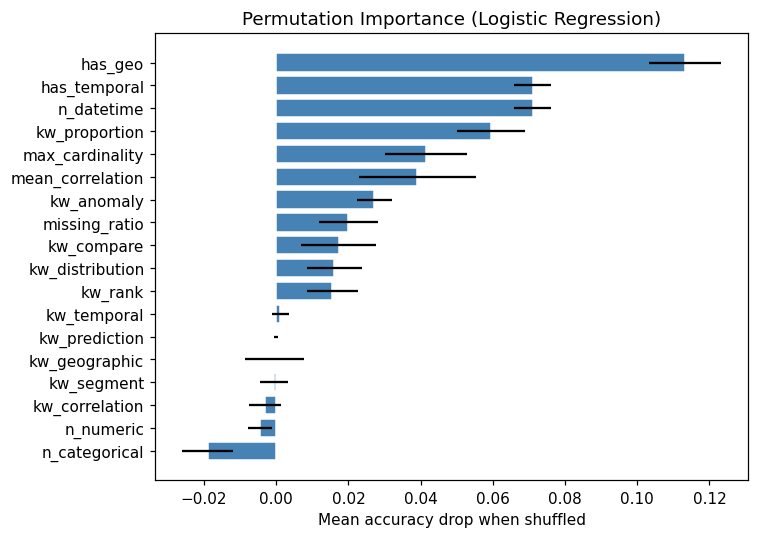

In [20]:
perm=perm_imp(BEST_ML_MODEL,Xte_df,y_test,n_repeats=30,random_state=RANDOM_STATE,
              n_jobs=1,scoring='accuracy')
perm_df=(pd.DataFrame({'feature':FEATURE_COLS,'importance':perm.importances_mean,
                        'std':perm.importances_std})
           .sort_values('importance',ascending=False))
print(f"Permutation Importance ({BEST_MODEL_NAME}, Pool C):")
print(perm_df.to_string(index=False))

core=BEST_ML_MODEL[-1] if hasattr(BEST_ML_MODEL,'named_steps') else BEST_ML_MODEL
has_impurity=hasattr(core,'feature_importances_')
n_plots=2 if has_impurity else 1
fig,axes=plt.subplots(1,n_plots,figsize=(7*n_plots,5))
if n_plots==1: axes=[axes]
si=np.argsort(perm.importances_mean)
axes[0].barh([FEATURE_COLS[i] for i in si],perm.importances_mean[si],
             xerr=perm.importances_std[si],color='steelblue',edgecolor='white')
axes[0].set_title(f'Permutation Importance ({BEST_MODEL_NAME})')
axes[0].set_xlabel('Mean accuracy drop when shuffled')
if has_impurity:
    imp_df=pd.DataFrame({'feature':FEATURE_COLS,'imp':core.feature_importances_}).sort_values('imp')
    axes[1].barh(imp_df['feature'],imp_df['imp'],color='darkorange',edgecolor='white')
    axes[1].set_title('Impurity (Gini) Importance')
plt.tight_layout(); plt.show()


---
## 11. Final Benchmark Results — Pool C

=== FINAL RESULTS — Pool C | Primary model: Logistic Regression ===

                     Accuracy@1  Accuracy@3     MRR  NDCG@3  Macro-F1
Model                                                                
Rule-based               0.7567      0.9500  0.8593  0.8765    0.6608
Logistic Regression      0.7233      0.9867  0.8497  0.8829    0.6400
Random Forest            0.9100      0.9833  0.9502  0.9563    0.8851
Gradient Boosting        0.8300      0.8933  0.8764  0.8695    0.8066
XGBoost                  0.8700      0.8933  0.9049  0.8843    0.8377
LightGBM                 0.9500      0.9833  0.9689  0.9710    0.9465


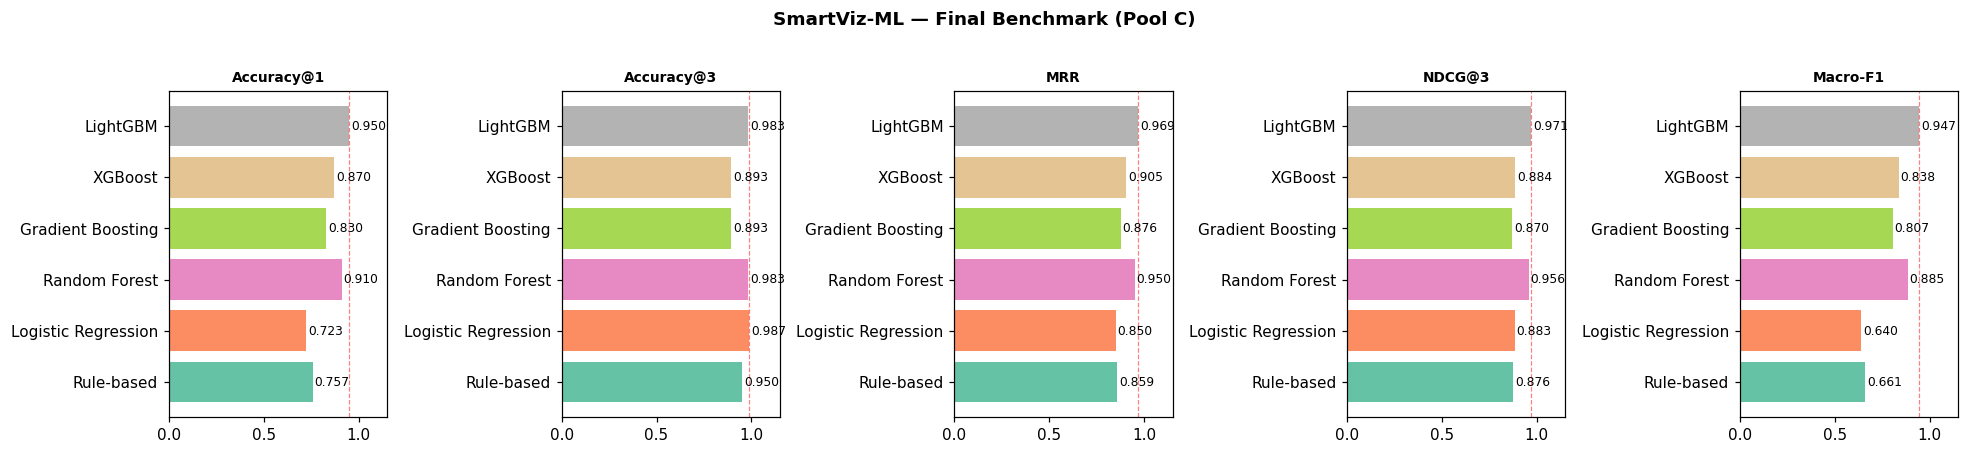

In [21]:
print(f"=== FINAL RESULTS — Pool C | Primary model: {BEST_MODEL_NAME} ===\n")
test_rows=[evaluate_model('Rule-based',rule_predict,X_test,y_test,pool_C,le_viz)]
for name,m in ml_models.items():
    test_rows.append(evaluate_model(name,make_ml_predict(m),X_test,y_test,pool_C,le_viz))
bench_df=pd.DataFrame(test_rows).set_index('Model')
print(bench_df.to_string())

metrics_p=['Accuracy@1','Accuracy@3','MRR','NDCG@3','Macro-F1']
fig,axes=plt.subplots(1,len(metrics_p),figsize=(18,4))
colors=plt.cm.Set2(np.linspace(0,1,len(bench_df)))
for ax,metric in zip(axes,metrics_p):
    vals=bench_df[metric]
    bars=ax.barh(vals.index,vals.values,color=colors)
    ax.set_xlim(0,1.15); ax.axvline(vals.max(),color='red',lw=0.8,linestyle='--',alpha=0.5)
    ax.set_title(metric,fontsize=9,fontweight='bold')
    for bar,v in zip(bars,vals.values): ax.text(v+0.01,bar.get_y()+bar.get_height()/2,f'{v:.3f}',va='center',fontsize=8)
plt.suptitle('SmartViz-ML — Final Benchmark (Pool C)',fontsize=12,fontweight='bold',y=1.02)
plt.tight_layout(); plt.show()


---
## 11b. Statistical Analysis (Bootstrap CI + Holm + effect size)

=== Bootstrap 95% CIs (n=2000) ===
                                      Acc@1                     MRR                  NDCG@3
Model                                                                                      
Rule-based           0.7567 [0.7067,0.8033]  0.8593 [0.8281,0.8865]  0.8765 [0.8469,0.9031]
Logistic Regression  0.7233 [0.6700,0.7700]  0.8497 [0.8220,0.8762]  0.8829 [0.8593,0.9060]
Random Forest        0.9100 [0.8767,0.9433]  0.9502 [0.9320,0.9682]  0.9563 [0.9375,0.9733]
Gradient Boosting    0.8300 [0.7833,0.8701]  0.8764 [0.8431,0.9068]  0.8695 [0.8325,0.9036]
XGBoost              0.8700 [0.8300,0.9067]  0.9049 [0.8744,0.9329]  0.8843 [0.8481,0.9205]
LightGBM             0.9500 [0.9233,0.9733]  0.9689 [0.9522,0.9842]  0.9710 [0.9531,0.9860]

=== All-pairs Wilcoxon (MRR) + Holm–Bonferroni correction ===
A                               B                                   stat       p_raw      p_holm    r_rb  sig
--------------------------------------------------------

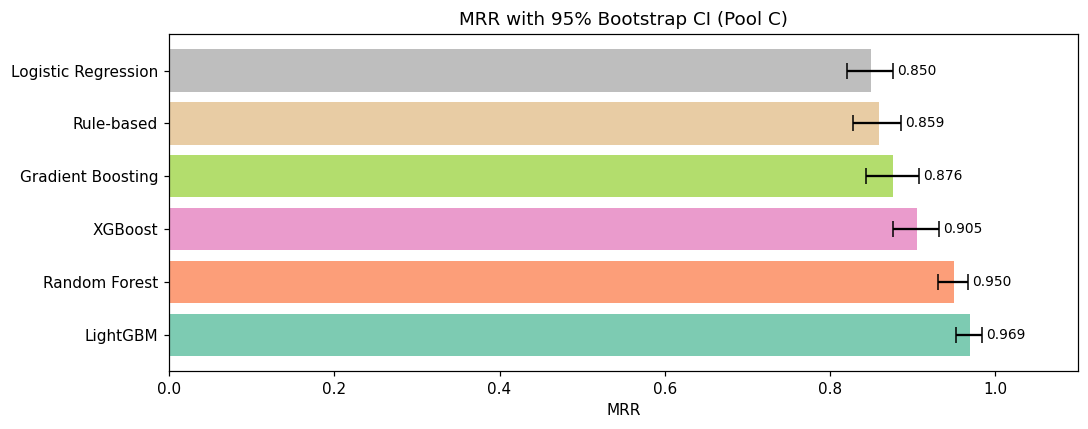

In [22]:
np.random.seed(RANDOM_STATE)
model_pq={}
model_pq['Rule-based']=per_query_metrics(rule_predict,X_test,y_test,pool_C,le_viz)
for name,m in ml_models.items():
    model_pq[name]=per_query_metrics(make_ml_predict(m),X_test,y_test,pool_C,le_viz)

# Bootstrap CIs
ci_rows=[]
for mname,(acc1,mrr,ndcg,_) in model_pq.items():
    am,alo,ahi=bootstrap_ci(acc1); mm,mlo,mhi=bootstrap_ci(mrr); nm,nlo,nhi=bootstrap_ci(ndcg)
    ci_rows.append({'Model':mname,
                    'Acc@1':f"{am:.4f} [{alo:.4f},{ahi:.4f}]",
                    'MRR':  f"{mm:.4f} [{mlo:.4f},{mhi:.4f}]",
                    'NDCG@3':f"{nm:.4f} [{nlo:.4f},{nhi:.4f}]"})
print("=== Bootstrap 95% CIs (n=2000) ===")
print(pd.DataFrame(ci_rows).set_index('Model').to_string())

# Wilcoxon + Holm
pairs=list(combinations(list(model_pq.keys()),2))
raw_p,stats_,rbs_,plabels=[],[],[],[]
for a,b in pairs:
    ma,mb=model_pq[a][1],model_pq[b][1]
    if np.array_equal(ma,mb): raw_p.append(1.0); stats_.append(0.0); rbs_.append(0.0)
    else:
        try: st,p=wilcoxon(ma,mb,alternative='two-sided'); r=rank_biserial_r(ma,mb)
        except ValueError: st,p,r=0.0,1.0,0.0
        raw_p.append(p); stats_.append(st); rbs_.append(r)
    plabels.append((a,b))
corr_p=holm_bonferroni(raw_p)

print("\n=== All-pairs Wilcoxon (MRR) + Holm–Bonferroni correction ===")
print(f"{'A':30s}  {'B':30s}  {'stat':>8}  {'p_raw':>10}  {'p_holm':>10}  {'r_rb':>6}  sig")
print("-"*100)
for (a,b),st,pr,ph,r in zip(plabels,stats_,raw_p,corr_p,rbs_):
    print(f"{a:30s}  {b:30s}  {st:8.1f}  {pr:10.6f}  {ph:10.6f}  {r:6.3f}  {'✓' if ph<0.05 else ''}")

# One-sided vs Rule-based
print("\n=== One-sided: ML > Rule-based (MRR) ===")
rb_mrr=model_pq['Rule-based'][1]
for mname in ml_models.keys():
    ml_mrr=model_pq[mname][1]
    if np.array_equal(ml_mrr,rb_mrr): print(f"  {mname}: identical"); continue
    try:
        st,p=wilcoxon(ml_mrr,rb_mrr,alternative='greater'); r=rank_biserial_r(ml_mrr,rb_mrr)
        print(f"  {mname:35s}: stat={st:.1f}  p={p:.6f}  r={r:.3f}  {'✓ p<0.05' if p<0.05 else 'n.s.'}")
    except ValueError as e: print(f"  {mname}: {e}")

# Plot bootstrap MRR
fig,ax=plt.subplots(figsize=(10,4))
order=sorted(model_pq.keys(),key=lambda m:model_pq[m][1].mean(),reverse=True)
colors=plt.cm.Set2(np.linspace(0,1,len(order)))
for idx,mn in enumerate(order):
    arr=model_pq[mn][1]; m,lo,hi=bootstrap_ci(arr)
    ax.barh(idx,m,color=colors[idx],alpha=0.85)
    ax.errorbar(m,idx,xerr=[[m-lo],[hi-m]],fmt='none',color='black',capsize=5,lw=1.5)
    ax.text(hi+0.005,idx,f"{m:.3f}",va='center',fontsize=9)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_xlabel('MRR'); ax.set_xlim(0,1.1)
ax.set_title('MRR with 95% Bootstrap CI (Pool C)'); plt.tight_layout(); plt.show()


---
## 11c. Granular Evaluation — Domain / Ambiguity / Chart Type

By Domain:
                 N  Accuracy@1  Accuracy@3     MRR  NDCG@3  Macro-F1
Model                                                               
Retail         151      0.7351      0.9868  0.8562  0.8878    0.6344
Banking         33      0.6970      1.0000  0.8384  0.8802    0.5417
Healthcare      32      0.7188      1.0000  0.8542  0.8921    0.6345
Manufacturing   42      0.7381      0.9524  0.8480  0.8671    0.6691
HR              42      0.6905      1.0000  0.8333  0.8764    0.6404

Ambiguous:
                 N  Accuracy@1  Accuracy@3     MRR  NDCG@3  Macro-F1
Model                                                               
Non-ambiguous  171      0.8246      0.9825  0.9063  0.9234    0.5656
Ambiguous      129      0.5891      0.9922  0.7745  0.8293    0.5507

By Chart:
               N  Accuracy@1  Accuracy@3     MRR  NDCG@3  Macro-F1
Model                                                             
line_chart    46      0.9565      1.0000  0.9783  0.9840    0.4889
bar_ch

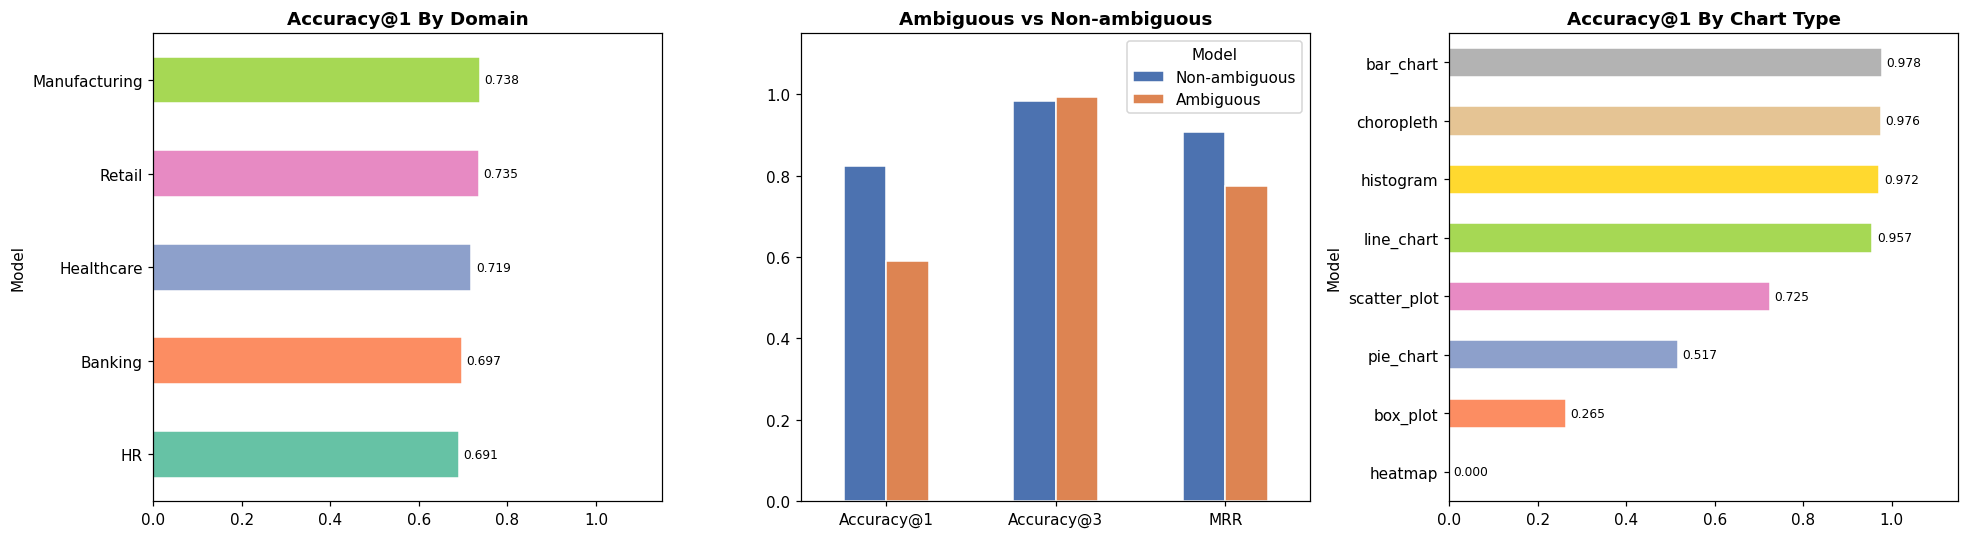

In [23]:
best_fn=make_ml_predict(BEST_ML_MODEL)
pool_C_ri=pool_C.reset_index(drop=True)

def eval_subset(label,mask):
    idx=np.where(mask)[0]
    if len(idx)==0: return None
    sub=pool_C_ri.iloc[idx].reset_index(drop=True)
    r=evaluate_model(label,best_fn,X_test[idx],y_test[idx],sub,le_viz)
    r['N']=int(len(idx)); return r

rows_d,rows_a,rows_v=[],[],[]
for dom in ['Retail','Banking','Healthcare','Manufacturing','HR']:
    r=eval_subset(dom,(pool_C_ri['domain'].values==dom)); 
    if r: rows_d.append(r)
for lbl,val in [("Non-ambiguous",False),("Ambiguous",True)]:
    r=eval_subset(lbl,(pool_C_ri['ambiguous'].values==val))
    if r: rows_a.append(r)
for viz in VIZ_TYPES:
    r=eval_subset(viz,(pool_C_ri['primary_viz'].values==viz))
    if r: rows_v.append(r)

cols_s=['N','Accuracy@1','Accuracy@3','MRR','NDCG@3','Macro-F1']
df_d=pd.DataFrame(rows_d).set_index('Model')
df_a=pd.DataFrame(rows_a).set_index('Model')
df_v=pd.DataFrame(rows_v).set_index('Model')
print("By Domain:"); print(df_d[cols_s].to_string())
print("\nAmbiguous:"); print(df_a[cols_s].to_string())
print("\nBy Chart:"); print(df_v[cols_s].to_string())

fig,axes=plt.subplots(1,3,figsize=(18,5))
for ax,df_sub,title in [(axes[0],df_d,'By Domain'),(axes[2],df_v,'By Chart Type')]:
    vals=df_sub['Accuracy@1'].sort_values()
    vals.plot(kind='barh',ax=ax,color=sns.color_palette('Set2',len(vals)),edgecolor='white')
    ax.set_xlim(0,1.15); ax.set_title(f'Accuracy@1 {title}',fontweight='bold')
    for i,v in enumerate(vals): ax.text(v+0.01,i,f'{v:.3f}',va='center',fontsize=8)
df_a[['Accuracy@1','Accuracy@3','MRR']].T.plot(kind='bar',ax=axes[1],
    color=['#4C72B0','#DD8452'],edgecolor='white')
axes[1].set_title('Ambiguous vs Non-ambiguous',fontweight='bold')
axes[1].set_ylim(0,1.15); axes[1].set_xticklabels(axes[1].get_xticklabels(),rotation=0)
plt.tight_layout(); plt.show()


---
## 11d. Confusion Matrix & Error Analysis

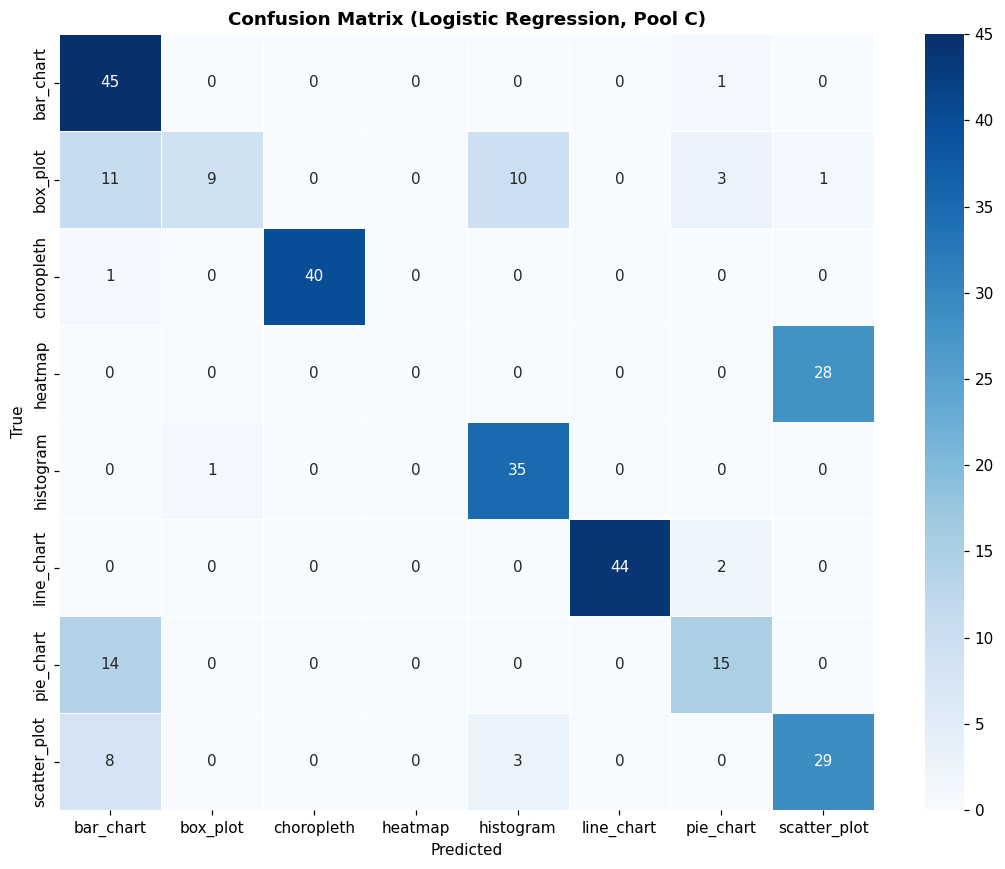

              precision    recall  f1-score   support

   bar_chart       0.57      0.98      0.72        46
    box_plot       0.90      0.26      0.41        34
  choropleth       1.00      0.98      0.99        41
     heatmap       0.00      0.00      0.00        28
   histogram       0.73      0.97      0.83        36
  line_chart       1.00      0.96      0.98        46
   pie_chart       0.71      0.52      0.60        29
scatter_plot       0.50      0.72      0.59        40

    accuracy                           0.72       300
   macro avg       0.68      0.67      0.64       300
weighted avg       0.70      0.72      0.68       300

Top confusions:
  heatmap              → scatter_plot        : 28
  pie_chart            → bar_chart           : 14
  box_plot             → bar_chart           : 11
  box_plot             → histogram           : 10
  scatter_plot         → bar_chart           : 8
  scatter_plot         → histogram           : 3
  box_plot             → pie_chart 

In [24]:
pred1l=[]
for i,(xr,yt) in enumerate(zip(X_test,y_test)):
    pred1l.append(le_viz.transform([best_fn(xr.reshape(1,-1),pool_C_ri.iloc[i]['query'])[0]])[0])
pred1=np.array(pred1l)
cm=confusion_matrix(y_test,pred1)
cm_df=pd.DataFrame(cm,index=le_viz.classes_,columns=le_viz.classes_)
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_df,annot=True,fmt='d',cmap='Blues',linewidths=0.5,ax=ax)
ax.set_title(f'Confusion Matrix ({BEST_MODEL_NAME}, Pool C)',fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()
print(classification_report(y_test,pred1,target_names=le_viz.classes_,zero_division=0))

print("Top confusions:")
conf=[(cm[i,j],le_viz.classes_[i],le_viz.classes_[j])
      for i in range(len(le_viz.classes_)) for j in range(len(le_viz.classes_))
      if i!=j and cm[i,j]>0]
for cnt,t,p in sorted(conf,reverse=True)[:10]:
    print(f"  {t:20s} → {p:20s}: {cnt}")


---
## 11e. Ablation Study
> Fresh RF estimator for each condition; Pool C evaluation only — no selection.


=== Ablation (RF, Pool A → Pool C) ===
                      Accuracy@1  Accuracy@3     MRR  NDCG@3  Macro-F1
Model                                                                 
Full features             0.8867      0.9900  0.9391  0.9510    0.8597
Meta-features only        0.8767      1.0000  0.9383  0.9545    0.8286
Intent keywords only      0.4733      0.6267  0.6137  0.5653    0.4461

Δ vs full:
                      Δ_Accuracy@1  Δ_Accuracy@3   Δ_MRR  Δ_NDCG@3  Δ_Macro-F1
Model                                                                         
Full features               0.0000        0.0000  0.0000    0.0000      0.0000
Meta-features only         -0.0100        0.0100 -0.0008    0.0035     -0.0311
Intent keywords only       -0.4134       -0.3633 -0.3254   -0.3857     -0.4136


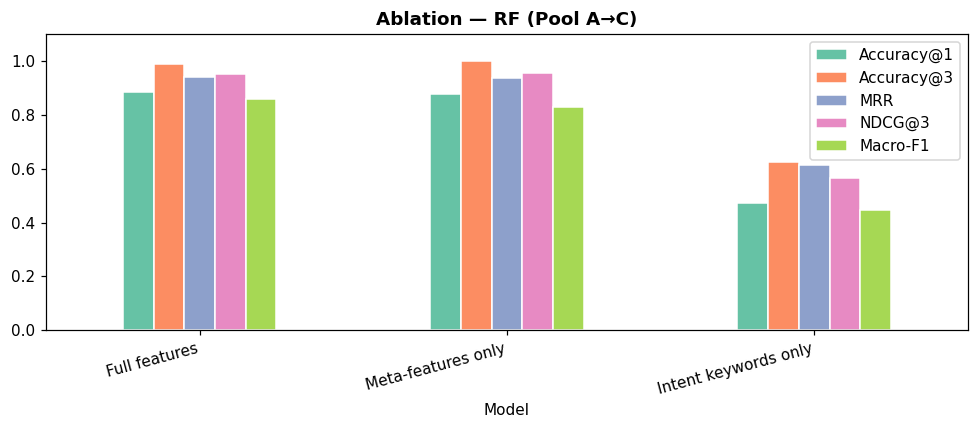

In [25]:
meta_idx  =[FEATURE_COLS.index(c) for c in META_FEATURE_COLS]
intent_idx=[FEATURE_COLS.index(c) for c in INTENT_KEYWORDS.keys()]

def abl_eval(Xtr,Xte,ytr,yte,df_te,label,cols):
    m=RandomForestClassifier(n_estimators=200,random_state=RANDOM_STATE,n_jobs=1)
    m.fit(pd.DataFrame(Xtr,columns=cols),ytr)
    return evaluate_model(label,make_ml_predict(m,cols=cols),Xte,yte,df_te,le_viz)

pool_C_ri2=pool_C.reset_index(drop=True)
abl=[
    abl_eval(X_train,        X_test,        y_train,y_test,pool_C_ri2,'Full features',      FEATURE_COLS),
    abl_eval(X_train[:,meta_idx],  X_test[:,meta_idx],  y_train,y_test,pool_C_ri2,'Meta-features only',  META_FEATURE_COLS),
    abl_eval(X_train[:,intent_idx],X_test[:,intent_idx],y_train,y_test,pool_C_ri2,'Intent keywords only',list(INTENT_KEYWORDS.keys())),
]
abl_df=pd.DataFrame(abl).set_index('Model')
metrics_a=['Accuracy@1','Accuracy@3','MRR','NDCG@3','Macro-F1']
full_v=abl_df.loc['Full features',metrics_a]
for c in metrics_a: abl_df[f'Δ_{c}']=(abl_df[c]-full_v[c]).round(4)
print("=== Ablation (RF, Pool A → Pool C) ==="); print(abl_df[metrics_a].to_string())
print("\nΔ vs full:"); print(abl_df[[f'Δ_{m}' for m in metrics_a]].to_string())
abl_df[metrics_a].plot(kind='bar',figsize=(9,4),color=sns.color_palette('Set2',5),edgecolor='white')
plt.title('Ablation — RF (Pool A→C)',fontweight='bold'); plt.ylim(0,1.1)
plt.xticks(rotation=15,ha='right'); plt.tight_layout(); plt.show()


---
## 12. Pool D — Final Held-Out Evaluation (touched exactly ONCE)

In [26]:
print(f"=== POOL D — Final Held-Out | Model: {BEST_MODEL_NAME} ===\n")
pool_d_result=evaluate_model(f"{BEST_MODEL_NAME} (Pool D)",
    make_ml_predict(BEST_ML_MODEL),X_poold,y_poold,pool_D,le_viz)
print(pd.DataFrame([pool_d_result]).set_index('Model').to_string())
gap_acc=pool_d_result['Accuracy@1']-bench_df.loc[BEST_MODEL_NAME,'Accuracy@1']
gap_mrr=pool_d_result['MRR']       -bench_df.loc[BEST_MODEL_NAME,'MRR']
verdict_d=("within ±0.05" if abs(gap_acc)<=0.05 else
           "within ±0.10" if abs(gap_acc)<=0.10 else "OUTSIDE ±0.10 — investigate")
print(f"\nGeneralisation gap (D vs C): Acc@1={gap_acc:+.4f}  MRR={gap_mrr:+.4f}  {verdict_d}")


=== POOL D — Final Held-Out | Model: Logistic Regression ===

                              Accuracy@1  Accuracy@3     MRR  NDCG@3  Macro-F1
Model                                                                         
Logistic Regression (Pool D)      0.6795      0.9872  0.8216  0.8619    0.5798

Generalisation gap (D vs C): Acc@1=-0.0438  MRR=-0.0281  within ±0.05


---
## 13. Human Evaluation
> Real CSV is the primary path. Synthetic data is gated and prominently flagged.


In [27]:
RESP_FILE     = 'D:\smartviz\human_eval_responses.csv'
USE_SYNTHETIC = not os.path.exists(RESP_FILE)

HE_QUERIES = [
    ('HQ01','Show me how total sales changed quarter by quarter','line_chart','temporal_num'),
    ('HQ02','Which five countries generated the most orders last year?','bar_chart','cat_rank'),
    ('HQ03','What does the distribution of individual order values look like?','histogram','num_dist'),
    ('HQ04','Do frequent customers also spend more per visit?','scatter_plot','num_num'),
    ('HQ05','What fraction of revenue comes from repeat versus new buyers?','pie_chart','cat_prop'),
    ('HQ06','How are VIP, loyal, and at-risk customers distributed?','bar_chart','cluster_cat'),
    ('HQ07','Show total revenue by country on a world map','choropleth','geo_num'),
    ('HQ08','Summarise the variability in delivery lead times','box_plot','num_dist'),
    ('HQ09','Give an overview of how all our KPIs relate to each other','heatmap','num_num_multi'),
    ('HQ10','Is there a seasonal pattern in weekly order volumes?','line_chart','temporal_num'),
    ('HQ11','What are the ten highest-grossing product categories?','bar_chart','cat_num'),
    ('HQ12','Show the full range of unit prices across our catalogue','histogram','num_dist'),
    ('HQ13','Break down our cost structure by expense category','pie_chart','cat_prop'),
    ('HQ14','Visualise the RFM space to identify natural clusters','scatter_plot','cluster_num'),
    ('HQ15','Display pairwise correlations for all RFM dimensions','heatmap','num_num_multi'),
]

pred_rows=[]
for qid,query,gt,pk in HE_QUERIES:
    prof=META_PROFILES.get(pk,META_PROFILES['cat_num'])
    x_q=np.array([[prof['n_numeric'],prof['n_categorical'],prof['n_datetime'],
                   prof['max_cardinality'],prof['mean_correlation'],prof['missing_ratio'],
                   prof['has_temporal'],prof['has_geo'],
                   *encode_query(query).values()]],dtype=float)
    proba=BEST_ML_MODEL.predict_proba(pd.DataFrame(x_q,columns=FEATURE_COLS))[0]
    ranked=[le_viz.classes_[i] for i in np.argsort(proba)[::-1]]
    hit1=int(ranked[0]==gt); rr=next((1/(i+1) for i,v in enumerate(ranked) if v==gt),0.0)
    pred_rows.append({'QueryID':qid,'Query':query,'GroundTruth':gt,
                      'Rank1':ranked[0],'Rank2':ranked[1],'Rank3':ranked[2],
                      'Accuracy@1':hit1,'RR':round(rr,4)})

pred_df=pd.DataFrame(pred_rows)
print(pred_df[['QueryID','GroundTruth','Rank1','Accuracy@1','RR']].to_string(index=False))

# Template CSV
with open('D:\smartviz\human_eval_template.csv','w') as f:
    f.write('evaluator_id,query_id,rank1_viz,rank2_viz,rank3_viz,Relevance,Readability,Usefulness,Interpretability\n')
    for _,r in pred_df.iterrows():
        f.write(f"E01,{r['QueryID']},{r['Rank1']},{r['Rank2']},{r['Rank3']},,,,\n")
print("Template written → human_eval_template.csv")


QueryID  GroundTruth        Rank1  Accuracy@1     RR
   HQ01   line_chart   line_chart           1 1.0000
   HQ02    bar_chart    bar_chart           1 1.0000
   HQ03    histogram    histogram           1 1.0000
   HQ04 scatter_plot scatter_plot           1 1.0000
   HQ05    pie_chart    bar_chart           0 0.3333
   HQ06    bar_chart    bar_chart           1 1.0000
   HQ07   choropleth   choropleth           1 1.0000
   HQ08     box_plot    histogram           0 0.2500
   HQ09      heatmap scatter_plot           0 0.5000
   HQ10   line_chart   line_chart           1 1.0000
   HQ11    bar_chart    bar_chart           1 1.0000
   HQ12    histogram    histogram           1 1.0000
   HQ13    pie_chart    bar_chart           0 0.3333
   HQ14 scatter_plot    bar_chart           0 0.5000
   HQ15      heatmap scatter_plot           0 0.5000
Template written → human_eval_template.csv


Results below are SYNTHETIC — DO NOT REPORT IN PAPER.
Recruit 10-20 evaluators and use human_eval_template.csv.


Likert (SYNTHETIC):
  Relevance           : 3.63 ± 0.92  ← BELOW 4.0
  Readability         : 3.62 ± 1.02  ← BELOW 4.0
  Usefulness          : 3.44 ± 0.99  ← BELOW 4.0
  Interpretability    : 3.57 ± 0.99  ← BELOW 4.0
Mean Cohen's κ (Relevance): 0.166


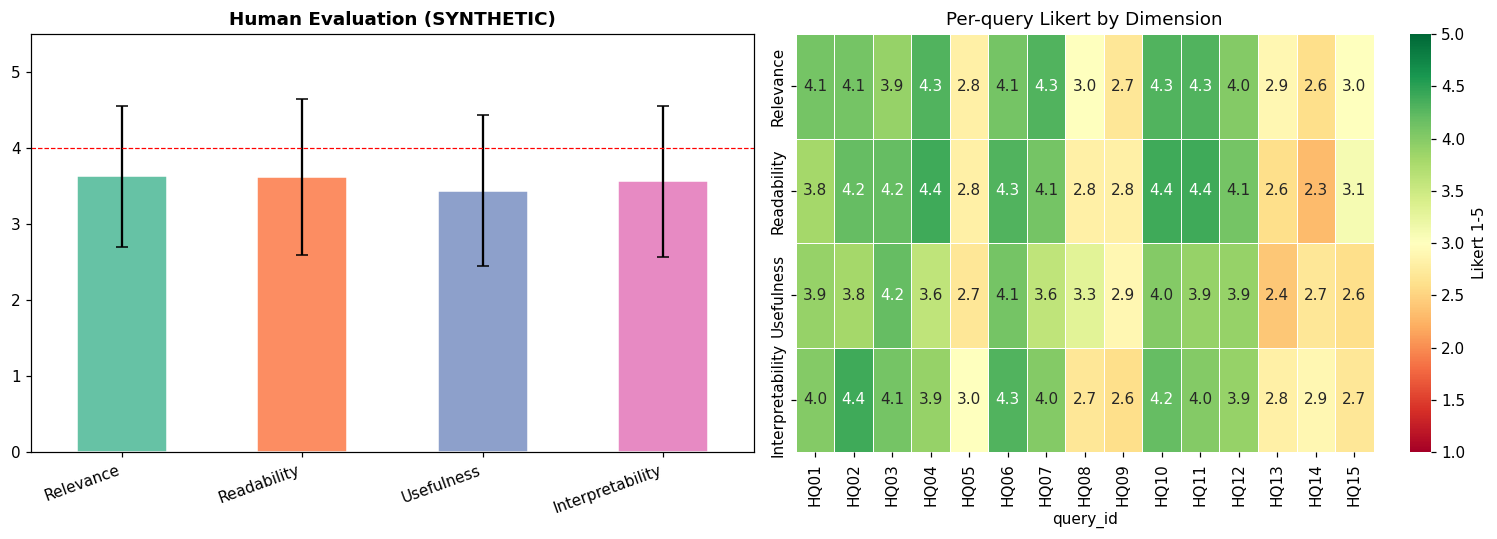

In [28]:
from sklearn.metrics import cohen_kappa_score
if USE_SYNTHETIC:
    print("="*65)
    print("WARNING: human_eval_responses.csv NOT FOUND.")
    print("Results below are SYNTHETIC — DO NOT REPORT IN PAPER.")
    print("Recruit 10-20 evaluators and use human_eval_template.csv.")
    print("="*65+"\n")
    np.random.seed(RANDOM_STATE)
    rows=[]
    for _,pr in pred_df.iterrows():
        base=4.2 if pr['Accuracy@1'] else 2.9
        for ev in range(10):
            rows.append({'evaluator_id':f'E{ev+1:02d}','query_id':pr['QueryID'],
                'Relevance':int(np.clip(round(np.random.normal(base,0.7)),1,5)),
                'Readability':int(np.clip(round(np.random.normal(base,0.8)),1,5)),
                'Usefulness':int(np.clip(round(np.random.normal(base-.2,0.8)),1,5)),
                'Interpretability':int(np.clip(round(np.random.normal(base-.1,0.7)),1,5))})
    responses=pd.DataFrame(rows); DATA_SOURCE='SYNTHETIC'
else:
    responses=pd.read_csv(RESP_FILE); DATA_SOURCE='real'
    print(f"Loaded {len(responses)} real evaluator responses.")

dim_m=responses[LIKERT_DIMS].mean().round(3); dim_s=responses[LIKERT_DIMS].std().round(3)
print(f"\nLikert ({DATA_SOURCE}):")
for d in LIKERT_DIMS:
    print(f"  {d:20s}: {dim_m[d]:.2f} ± {dim_s[d]:.2f}{'  ← BELOW 4.0' if dim_m[d]<4.0 else ''}")

eids=responses['evaluator_id'].unique()
kappas=[]
for i in range(len(eids)):
    for j in range(i+1,len(eids)):
        ri=responses[responses['evaluator_id']==eids[i]].sort_values('query_id')['Relevance'].values
        rj=responses[responses['evaluator_id']==eids[j]].sort_values('query_id')['Relevance'].values
        if len(ri)==len(rj) and len(ri)>1: kappas.append(cohen_kappa_score(ri,rj))
print(f"Mean Cohen's κ (Relevance): {np.mean(kappas):.3f}" if kappas else "κ: insufficient pairs")

fig,axes=plt.subplots(1,2,figsize=(14,5))
dim_m.plot(kind='bar',yerr=dim_s,ax=axes[0],color=sns.color_palette('Set2',4),capsize=4,edgecolor='white')
axes[0].set_title(f'Human Evaluation ({DATA_SOURCE})',fontweight='bold')
axes[0].set_ylim(0,5.5); axes[0].axhline(4,color='red',lw=0.8,linestyle='--')
axes[0].set_xticklabels(axes[0].get_xticklabels(),rotation=20,ha='right')
per_q=responses.groupby('query_id')[LIKERT_DIMS].mean().round(2)
per_q=per_q.join(pred_df.set_index('QueryID')[['GroundTruth','Accuracy@1']])
sns.heatmap(per_q[LIKERT_DIMS].T,ax=axes[1],vmin=1,vmax=5,cmap='RdYlGn',
            annot=True,fmt='.1f',linewidths=0.4,cbar_kws={'label':'Likert 1-5'})
axes[1].set_title('Per-query Likert by Dimension')
plt.tight_layout(); plt.show()


---
## 14. Business Decision Support

In [29]:
INSIGHTS={
    'line_chart':   ('Trend analysis','Identify growth patterns. Cross-reference with operational events.'),
    'bar_chart':    ('Ranking/Comparison','Identify top and bottom performers. Prioritise resource allocation.'),
    'scatter_plot': ('Relationship exploration','Examine co-movement. Correlation ≠ causation.'),
    'pie_chart':    ('Proportional breakdown','Check segment dominance. High concentration may warrant diversification.'),
    'histogram':    ('Distribution profiling','Assess skewness and extreme values. Investigate outliers.'),
    'box_plot':     ('Spread & outlier review','Wide IQR signals high variability. Extreme values merit follow-up.'),
    'heatmap':      ('Correlation overview','High inter-variable correlations may indicate redundancy.'),
    'choropleth':   ('Geographic overview','Identify regional patterns. Can inform geo-targeted decisions.'),
}

def smartviz_chain(query,profile_key='cat_num',top_n=3):
    prof=META_PROFILES.get(profile_key,META_PROFILES['cat_num'])
    x=np.array([[prof['n_numeric'],prof['n_categorical'],prof['n_datetime'],
                 prof['max_cardinality'],prof['mean_correlation'],prof['missing_ratio'],
                 prof['has_temporal'],prof['has_geo'],*encode_query(query).values()]],dtype=float)
    proba=BEST_ML_MODEL.predict_proba(pd.DataFrame(x,columns=FEATURE_COLS))[0]
    ranked=[(le_viz.classes_[i],round(float(proba[i]),4)) for i in np.argsort(proba)[::-1]]
    rows=[]
    for rank,(viz,score) in enumerate(ranked[:top_n],1):
        title,rec=INSIGHTS.get(viz,('—','—'))
        rows.append({'Rank':rank,'Visualization':viz,'Score':score,'Insight':title,'Recommendation':rec})
    return pd.DataFrame(rows)

for q,pk in [("How do sales evolve over time?","temporal_num"),
             ("Which products generate the most revenue?","cat_rank"),
             ("Is there a correlation between quantity and price?","num_num"),
             ("Where are our customers geographically?","geo_num")]:
    print(f"\nQuery: {q}")
    print(smartviz_chain(q,pk).to_string(index=False))



Query: How do sales evolve over time?
 Rank Visualization  Score                  Insight                                                     Recommendation
    1    line_chart 0.9844           Trend analysis Identify growth patterns. Cross-reference with operational events.
    2  scatter_plot 0.0064 Relationship exploration                      Examine co-movement. Correlation ≠ causation.
    3     histogram 0.0043   Distribution profiling          Assess skewness and extreme values. Investigate outliers.

Query: Which products generate the most revenue?
 Rank Visualization  Score                Insight                                                           Recommendation
    1     bar_chart 0.9960     Ranking/Comparison      Identify top and bottom performers. Prioritise resource allocation.
    2     histogram 0.0019 Distribution profiling                Assess skewness and extreme values. Investigate outliers.
    3     pie_chart 0.0008 Proportional breakdown Check segment do

---
## 15. Cross-Domain Generalisation of Intent Features 

In [30]:
EXT_ITEMS=[
    ("temporal_num","How has monthly employee headcount changed this year?","line_chart",False,"HR"),
    ("temporal_num","Plot voluntary turnover rate quarter by quarter","line_chart",False,"HR"),
    ("temporal_cat","Compare attrition trends across departments over past year","line_chart",True,"HR"),
    ("cat_rank","Which five departments have the highest attrition count?","bar_chart",False,"HR"),
    ("cat_num","Compare mean job satisfaction scores across business units","bar_chart",True,"HR"),
    ("cluster_cat","How many employees fall into each performance tier?","bar_chart",True,"HR"),
    ("num_num","Does years of experience correlate with monthly income?","scatter_plot",False,"HR"),
    ("num_num","Is there a link between distance from home and job satisfaction?","scatter_plot",False,"HR"),
    ("cluster_num","Group employees by tenure and income to spot clusters","scatter_plot",True,"HR"),
    ("num_anom","Flag employees whose income and performance look unusual","scatter_plot",True,"HR"),
    ("cat_prop","What share of the workforce is in each education level?","pie_chart",True,"HR"),
    ("cat_prop","Break down voluntary exits by marital status category","pie_chart",True,"HR"),
    ("num_dist","What does the distribution of monthly incomes look like?","histogram",False,"HR"),
    ("num_dist","Show the distribution of years at the company","histogram",False,"HR"),
    ("num_dist","How are employee ages distributed?","histogram",False,"HR"),
    ("num_dist","Summarise variability in monthly income across job levels","box_plot",False,"HR"),
    ("num_dist_multi","Do high-performers show less income variability?","box_plot",True,"HR"),
    ("num_dist_multi","Compare satisfaction score spread across departments","box_plot",True,"HR"),
    ("num_num_multi","Show pairwise correlations across all numeric HR indicators","heatmap",False,"HR"),
    ("num_num_multi","Which HR metrics co-vary most strongly with attrition risk?","heatmap",True,"HR"),
    ("geo_num","Map headcount by office location across global sites","choropleth",False,"HR"),
    ("geo_num","Which regions show the highest voluntary turnover rates?","choropleth",True,"HR"),
    ("geo_num","Show attrition density by country","choropleth",False,"HR"),
    ("temporal_num","How has voluntary turnover evolved over two years?","line_chart",False,"HR"),
    ("cat_num","Which department has the highest absenteeism rate?","bar_chart",False,"HR"),
    ("num_num","Does training hours completed predict promotion likelihood?","scatter_plot",True,"HR"),
    ("cat_prop","How is our headcount split across business functions?","pie_chart",True,"HR"),
    ("num_dist","How are performance rating scores distributed?","histogram",False,"HR"),
    ("num_dist_multi","Compare engagement score variability across departments","box_plot",True,"HR"),
    ("num_num_multi","Show how all employee engagement dimensions relate","heatmap",True,"HR"),
]

ext_rows=[]
for pk,q,viz,ambig,dom in EXT_ITEMS:
    prof=META_PROFILES.get(pk,META_PROFILES['cat_num'])
    ext_rows.append({'query':q,'primary_viz':viz,'ambiguous':ambig,'domain':dom,**prof,**encode_query(q)})
pool_ext=pd.DataFrame(ext_rows)
pool_ext['label']=le_viz.transform(pool_ext['primary_viz'])
X_ext=pool_ext[FEATURE_COLS].values.astype(float)
y_ext=pool_ext['label'].values

print(f"Cross-domain set: {len(pool_ext)} HR Analytics queries")
ext_rows_res=[evaluate_model('Rule-based',rule_predict,X_ext,y_ext,pool_ext,le_viz)]
for name,m in ml_models.items():
    ext_rows_res.append(evaluate_model(name,make_ml_predict(m),X_ext,y_ext,pool_ext,le_viz))
ext_df=pd.DataFrame(ext_rows_res).set_index('Model')
print("\n=== Cross-Domain Generalisation Results ==="); print(ext_df.to_string())
print("\n=== Generalisation gap (Pool C → HR domain) ===")
for mn in ext_df.index:
    if mn in bench_df.index:
        gap=ext_df.loc[mn,'Accuracy@1']-bench_df.loc[mn,'Accuracy@1']
        print(f"  {mn:35s}: C={bench_df.loc[mn,'Accuracy@1']:.4f}  HR={ext_df.loc[mn,'Accuracy@1']:.4f}  gap={gap:+.4f}  {'✓ ≤0.10' if abs(gap)<=0.10 else '⚠ >0.10'}")


Cross-domain set: 30 HR Analytics queries

=== Cross-Domain Generalisation Results ===
                     Accuracy@1  Accuracy@3     MRR  NDCG@3  Macro-F1
Model                                                                
Rule-based               0.7333      0.9000  0.8306  0.8341    0.6639
Logistic Regression      0.6667      0.9333  0.8003  0.8262    0.5694
Random Forest            0.8667      0.9333  0.9150  0.9087    0.8444
Gradient Boosting        0.6667      0.8333  0.7736  0.7718    0.6571
XGBoost                  0.8000      0.8333  0.8533  0.8210    0.7389
LightGBM                 0.9333      0.9333  0.9417  0.9333    0.9306

=== Generalisation gap (Pool C → HR domain) ===
  Rule-based                         : C=0.7567  HR=0.7333  gap=-0.0234  ✓ ≤0.10
  Logistic Regression                : C=0.7233  HR=0.6667  gap=-0.0566  ✓ ≤0.10
  Random Forest                      : C=0.9100  HR=0.8667  gap=-0.0433  ✓ ≤0.10
  Gradient Boosting                  : C=0.8300  HR=0.6667  g

---
## 16. Benchmark Transparency Table

               Total  Ambiguous Ambiguous%  line_chart  bar_chart  scatter_plot  pie_chart  histogram  box_plot  heatmap  choropleth
Domain                                                                                                                              
Retail           151         60        40%          25         31            22         13         15        16       11          18
Banking           33         13        39%           6          3             4          3          5         2        4           6
Healthcare        32         13        41%           5          3             3          3          5         4        4           5
Manufacturing     42         20        48%           7          4             5          5          5         6        4           6
HR                42         23        55%           3          5             6          5          6         6        5           6
TOTAL            300        129        43%          46         46    

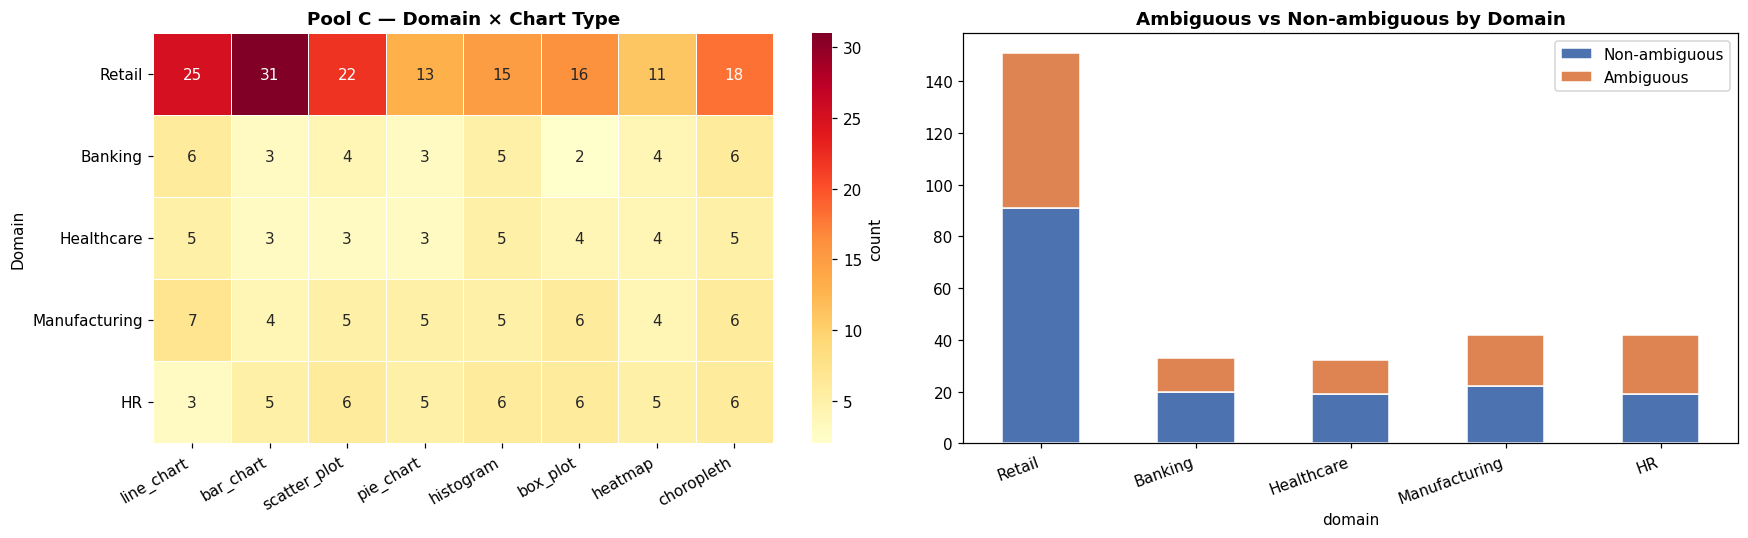

In [31]:
DOMAINS_T=['Retail','Banking','Healthcare','Manufacturing','HR']
rows_t=[]
for dom in DOMAINS_T:
    sub=pool_C[pool_C['domain']==dom]
    ct=sub['primary_viz'].value_counts().to_dict()
    row={'Domain':dom,'Total':len(sub),'Ambiguous':int(sub['ambiguous'].sum()),
         'Ambiguous%':f"{sub['ambiguous'].mean()*100:.0f}%"}
    for v in VIZ_TYPES: row[v]=ct.get(v,0)
    rows_t.append(row)
tot={'Domain':'TOTAL','Total':len(pool_C),'Ambiguous':int(pool_C['ambiguous'].sum()),
     'Ambiguous%':f"{pool_C['ambiguous'].mean()*100:.0f}%"}
for v in VIZ_TYPES: tot[v]=int((pool_C['primary_viz']==v).sum())
rows_t.append(tot)
transp=pd.DataFrame(rows_t).set_index('Domain')
print(transp.to_string())

fig,axes=plt.subplots(1,2,figsize=(16,5))
sns.heatmap(transp[VIZ_TYPES].iloc[:-1],ax=axes[0],annot=True,fmt='d',
            cmap='YlOrRd',linewidths=0.5,cbar_kws={'label':'count'})
axes[0].set_title('Pool C — Domain × Chart Type',fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(),rotation=30,ha='right')
dc=pool_C.groupby(['domain','ambiguous']).size().unstack(fill_value=0).reindex(DOMAINS_T)
dc.columns=['Non-ambiguous','Ambiguous']
dc.plot(kind='bar',stacked=True,ax=axes[1],color=['#4C72B0','#DD8452'],edgecolor='white')
axes[1].set_title('Ambiguous vs Non-ambiguous by Domain',fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(),rotation=20,ha='right')
plt.tight_layout(); plt.show()


---
## 17. Model Export

In [32]:
os.makedirs('models',exist_ok=True)
joblib.dump(BEST_ML_MODEL,  'models/smartviz_best_model.joblib')
joblib.dump(le_viz,          'models/smartviz_label_encoder.joblib')
joblib.dump(scaler_rfm,      'models/smartviz_rfm_scaler.joblib')
joblib.dump(best_fc_model,   'models/forecasting_model.joblib')
joblib.dump(km,              'models/segmentation_model.joblib')
joblib.dump(iso,             'models/anomaly_model.joblib')
meta_ex={'FEATURE_COLS':FEATURE_COLS,'VIZ_TYPES':VIZ_TYPES,'SEGMENT_NAMES':SEGMENT_NAMES,
          'best_model_name':BEST_MODEL_NAME,'best_fc_name':best_fc_name,'n_clusters':N_CLUSTERS,
          'pool_c_acc1':float(bench_df.loc[BEST_MODEL_NAME,'Accuracy@1']),
          'pool_c_mrr': float(bench_df.loc[BEST_MODEL_NAME,'MRR']),
          'intent_keywords':INTENT_KEYWORDS}
with open('models/smartviz_meta.json','w') as f: json.dump(meta_ex,f,indent=2)
for fn in os.listdir('models'):
    sz=os.path.getsize(f'models/{fn}')/1024**2
    print(f"  ✓  models/{fn:<40s}  {sz:.2f} MB")

# Round-trip test
rf_c=joblib.load('models/smartviz_best_model.joblib')
le_c=joblib.load('models/smartviz_label_encoder.joblib')
tq="Show me how sales evolved over the past year"
xrt=np.array([[2,0,1,0,0.4,0.01,1,0,*encode_query(tq).values()]],dtype=float)
top1=le_c.classes_[np.argmax(rf_c.predict_proba(pd.DataFrame(xrt,columns=FEATURE_COLS))[0])]
print(f"\nRound-trip: '{tq}' → {top1}  {'✓ PASS' if top1=='line_chart' else '✗ FAIL'}")


  ✓  models/anomaly_model.joblib                      0.71 MB
  ✓  models/forecasting_model.joblib                  0.33 MB
  ✓  models/segmentation_model.joblib                 0.02 MB
  ✓  models/smartviz_best_model.joblib                0.00 MB
  ✓  models/smartviz_label_encoder.joblib             0.00 MB
  ✓  models/smartviz_meta.json                        0.00 MB
  ✓  models/smartviz_rfm_scaler.joblib                0.00 MB

Round-trip: 'Show me how sales evolved over the past year' → line_chart  ✓ PASS


---
## 18. Clean-Kernel Smoke Test 


In [33]:
print("=== SmartViz-ML: Clean-Kernel Smoke Test ===\n")
checks=[
    ("df loaded",              lambda: len(df)>0),
    ("rfm.Segment exists",     lambda: 'Segment' in rfm.columns),
    ("Pool A >= 200",          lambda: len(pool_A)>=200),
    ("Pool B >= 60",           lambda: len(pool_B)>=60),
    ("Pool C == 300",          lambda: len(pool_C)==300),
    ("Pool C has domain col",  lambda: 'domain' in pool_C.columns),
    ("Pool C no NaN domain",   lambda: pool_C['domain'].notna().all()),
    ("Pool D >= 60",           lambda: len(pool_D)>=60),
    ("le_viz 8 classes",       lambda: len(le_viz.classes_)==8),
    ("BEST_MODEL_NAME set",    lambda: BEST_MODEL_NAME in ml_models),
    ("BEST selected by CV-MRR", lambda: 'cv_mrr' in val_df.columns and val_df.loc[BEST_MODEL_NAME,'cv_mrr'] == val_df[val_df.index.isin(ml_models.keys())]['cv_mrr'].max()),
    ("bench_df complete",      lambda: set(ml_models.keys()).issubset(set(bench_df.index))),
    ("pool_d_result exists",   lambda: pool_d_result is not None),
    ("abl_df exists",          lambda: abl_df is not None and len(abl_df)>0),
    ("responses loaded",       lambda: responses is not None and len(responses)>0),
    ("ext_df exists",          lambda: ext_df is not None and len(ext_df)>0),
    ("Feature vector 18",      lambda: len(FEATURE_COLS)==18),
    ("Models exported",        lambda: os.path.exists('models/smartviz_best_model.joblib')),
    ("Leakage CLEAN/ACCEPT",   lambda: 'CLEAN' in verdict or 'ACCEPTABLE' in verdict),
    ("TS folds = 5",           lambda: N_TS_SPLITS==5),
    ("TS test size = 3",       lambda: TS_TEST_SIZE==3),
]
ok_all=True
for name,fn in checks:
    try: ok=fn()
    except Exception as e: ok=False; name=f"{name} [ERR:{e}]"
    ok_all=ok_all and ok
    print(f"  {'OK PASS' if ok else 'XX FAIL'}  {name}")

print()
if ok_all: print("ALL CHECKS PASSED — notebook is reproducible from a clean kernel.")
else:      print("SOME CHECKS FAILED — see above.")

print(f"\n  Primary model  : {BEST_MODEL_NAME}")
print(f"  Pool C size    : {len(pool_C)}")
print(f"  Pool C Acc@1   : {bench_df.loc[BEST_MODEL_NAME,'Accuracy@1']:.4f}")
print(f"  Pool C MRR     : {bench_df.loc[BEST_MODEL_NAME,'MRR']:.4f}")
print(f"  Pool C Macro-F1: {bench_df.loc[BEST_MODEL_NAME,'Macro-F1']:.4f}")
print(f"  Pool D gap     : {pool_d_result['Accuracy@1']-bench_df.loc[BEST_MODEL_NAME,'Accuracy@1']:+.4f}")
print(f"  Forecasting CV : {N_TS_SPLITS}-fold, {TS_TEST_SIZE}-month horizon")
print(f"  Human eval     : {'REAL' if not USE_SYNTHETIC else 'SYNTHETIC — REPLACE BEFORE SUBMISSION'}")
print(f"  SHAP           : replaced by permutation importance (environment constraint)")
print(f"  XGBoost/LGB    : {'included' if XGB_AVAILABLE or LGB_AVAILABLE else 'excluded — not available'}")


=== SmartViz-ML: Clean-Kernel Smoke Test ===

  OK PASS  df loaded
  OK PASS  rfm.Segment exists
  OK PASS  Pool A >= 200
  OK PASS  Pool B >= 60
  OK PASS  Pool C == 300
  OK PASS  Pool C has domain col
  OK PASS  Pool C no NaN domain
  OK PASS  Pool D >= 60
  OK PASS  le_viz 8 classes
  OK PASS  BEST_MODEL_NAME set
  OK PASS  BEST selected by CV-MRR
  OK PASS  bench_df complete
  OK PASS  pool_d_result exists
  OK PASS  abl_df exists
  OK PASS  responses loaded
  OK PASS  ext_df exists
  OK PASS  Feature vector 18
  OK PASS  Models exported
  OK PASS  Leakage CLEAN/ACCEPT
  OK PASS  TS folds = 5
  OK PASS  TS test size = 3

ALL CHECKS PASSED — notebook is reproducible from a clean kernel.

  Primary model  : Logistic Regression
  Pool C size    : 300
  Pool C Acc@1   : 0.7233
  Pool C MRR     : 0.8497
  Pool C Macro-F1: 0.6400
  Pool D gap     : -0.0438
  Forecasting CV : 5-fold, 3-month horizon
  Human eval     : SYNTHETIC — REPLACE BEFORE SUBMISSION
  SHAP           : replaced by p